# Notebook 2 — EDA
**Dataset:** `rmr_dataset.csv` — 1000 samples, 200 per class

Going through distributions, correlations, span/depth effects and noise impact.
Sections 6-8 are the most interesting — span and depth effects on support targets.


## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

CLASS_COLORS   = {'I':'#2ecc71','II':'#3498db','III':'#f39c12','IV':'#e67e22','V':'#e74c3c'}
CLASS_ORDER    = ['I', 'II', 'III', 'IV', 'V']
COLORS_ORDERED = [CLASS_COLORS[c] for c in CLASS_ORDER]

# All 9 input features
RMR_FEATURE_COLS = ['UCS_MPa','RQD_percent','Joint_Spacing_m',
                    'Joint_Condition','Groundwater','Joint_Orientation_adj']
NEW_FEATURE_COLS = ['Excavation_Span_m','Depth_m','Excavation_Method']
FEATURE_COLS     = RMR_FEATURE_COLS + NEW_FEATURE_COLS

# All 4 regression/classification targets
TARGET_COLS = ['RMR','Bolt_Density_per_m2','Bolt_Length_m','Shotcrete_mm']

print(f'Total input features : {len(FEATURE_COLS)}')
print(f'Target variables     : {TARGET_COLS}')

Total input features : 9
Target variables     : ['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']


---
## 1. Load Data


In [2]:
df = pd.read_csv('rmr_dataset.csv')

CLASS_COL = 'True_Rock_Class' if 'True_Rock_Class' in df.columns else 'Rock_Class'
print(f'Classification column : {CLASS_COL}')
print(f'Shape                 : {df.shape}')
print(f'\nAll columns:')
for col in df.columns:
    print(f'  {col:<30} [{df[col].dtype}]')

Classification column : True_Rock_Class
Shape                 : (1000, 19)

All columns:
  UCS_MPa                        [float64]
  RQD_percent                    [float64]
  Joint_Spacing_m                [float64]
  Joint_Condition                [int64]
  Groundwater                    [int64]
  Joint_Orientation_adj          [int64]
  Excavation_Span_m              [float64]
  Depth_m                        [float64]
  Excavation_Method              [int64]
  RMR                            [int64]
  True_Rock_Class                [object]
  Measured_Rock_Class            [object]
  Bolt_Density_per_m2            [float64]
  Bolt_Length_m                  [float64]
  Shotcrete_mm                   [float64]
  UCS_clean                      [float64]
  RQD_clean                      [float64]
  JS_clean                       [float64]
  Depth_factor                   [float64]


In [3]:
df.head(10)

,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method,RMR,True_Rock_Class,Measured_Rock_Class,Bolt_Density_per_m2,Bolt_Length_m,Shotcrete_mm,UCS_clean,RQD_clean,JS_clean,Depth_factor
0,207.89,88.69,1.6430,1,2,0,15.71,697.0,0,84,I,I,0.0,4.33,0.0,216.09,88.78,1.8303,1.042
1,218.46,85.46,1.2301,1,2,0,13.93,586.9,0,82,I,I,0.0,3.82,0.0,223.41,88.87,1.0727,1.030
2,114.45,88.73,1.5975,1,2,-2,15.61,327.0,1,82,I,I,0.0,4.79,0.0,106.57,83.09,1.6197,1.045
3,169.92,100.00,1.6843,1,2,0,13.99,734.0,1,92,I,I,0.0,4.28,0.0,165.57,96.65,1.6403,1.040
4,129.48,85.85,1.7546,1,1,-2,13.18,589.5,1,82,I,I,0.0,4.17,0.0,120.97,82.29,1.6021,1.107
5,232.35,87.81,0.8377,1,3,0,7.52,612.6,0,84,I,I,0.0,2.06,0.0,228.01,84.68,0.8700,1.025
6,205.89,87.12,0.9840,1,1,0,5.83,641.9,0,82,I,I,0.0,2.00,0.0,208.35,89.24,0.9935,1.046
7,171.87,96.51,1.3774,1,1,0,14.83,437.4,0,87,I,I,0.0,4.00,0.0,216.81,94.34,1.3392,1.000
8,191.70,96.72,1.5652,1,1,0,5.01,403.4,1,85,I,I,0.0,2.01,0.0,164.81,92.55,1.5009,1.014
9,205.98,96.92,2.0368,2,1,0,15.50,460.0,0,84,I,I,0.0,4.22,0.0,187.16,86.94,1.5091,1.018


In [4]:
print('Missing values per column:')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing  : {missing.sum()}')
print(f'Duplicate rows : {df.duplicated().sum()}')
print(f'Total samples  : {len(df)}')

Missing values per column:
UCS_MPa                  0
RQD_percent              0
Joint_Spacing_m          0
Joint_Condition          0
Groundwater              0
Joint_Orientation_adj    0
Excavation_Span_m        0
Depth_m                  0
Excavation_Method        0
RMR                      0
True_Rock_Class          0
Measured_Rock_Class      0
Bolt_Density_per_m2      0
Bolt_Length_m            0
Shotcrete_mm             0
UCS_clean                0
RQD_clean                0
JS_clean                 0
Depth_factor             0
dtype: int64

Total missing  : 0
Duplicate rows : 0
Total samples  : 1000


In [5]:
df.describe().round(2)

,UCS_MPa,RQD_percent,Joint_Spacing_m,Joint_Condition,Groundwater,Joint_Orientation_adj,Excavation_Span_m,Depth_m,Excavation_Method,RMR,Bolt_Density_per_m2,Bolt_Length_m,Shotcrete_mm,UCS_clean,RQD_clean,JS_clean,Depth_factor
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,75.80,53.61,0.57,2.86,2.93,-5.63,9.95,467.90,0.48,49.00,0.68,4.95,98.37,75.80,53.66,0.57,1.34
std,62.47,29.38,0.55,1.30,1.36,4.47,3.42,244.88,0.50,28.76,0.65,1.61,86.53,61.67,29.13,0.54,0.21
min,1.00,0.00,0.01,1.00,1.00,-12.00,4.02,50.30,0.00,-3.00,0.00,2.00,0.00,1.00,0.22,0.01,1.00
25%,23.32,26.76,0.10,2.00,2.00,-10.00,6.89,256.20,0.00,25.00,0.16,3.53,18.30,23.47,24.85,0.10,1.10
50%,59.80,56.88,0.39,3.00,3.00,-5.00,9.86,469.75,0.00,50.00,0.44,5.00,85.85,58.49,57.79,0.41,1.50
75%,110.25,79.40,0.89,4.00,4.00,-2.00,12.93,669.08,1.00,77.00,1.00,6.70,167.35,112.71,80.20,0.93,1.50
max,281.08,100.00,2.51,5.00,5.00,0.00,16.00,899.40,1.00,92.00,1.78,7.00,250.00,249.03,99.95,2.00,1.50


---
## 2. Class Distribution


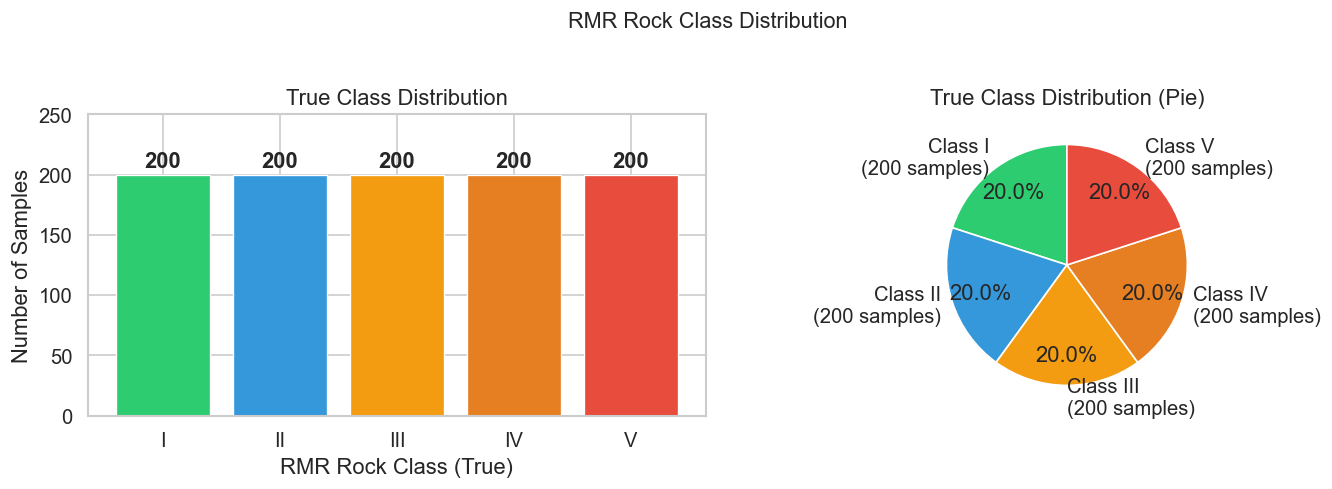

In [6]:
true_counts = df[CLASS_COL].value_counts().reindex(CLASS_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(CLASS_ORDER, true_counts.values,
                   color=COLORS_ORDERED, edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('RMR Rock Class (True)')
axes[0].set_ylabel('Number of Samples')
axes[0].set_title('True Class Distribution')
axes[0].set_ylim(0, 250)
for bar, val in zip(bars, true_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontweight='bold')

labels = [f'Class {c}\n({v} samples)' for c, v in zip(CLASS_ORDER, true_counts.values)]
axes[1].pie(true_counts.values, labels=labels, colors=COLORS_ORDERED,
            autopct='%1.1f%%', startangle=90, pctdistance=0.75)
axes[1].set_title('True Class Distribution (Pie)')

plt.suptitle('RMR Rock Class Distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png')
plt.show()

---
## 3. RMR89 Feature Distributions
Checking that noisy inputs look physically reasonable.


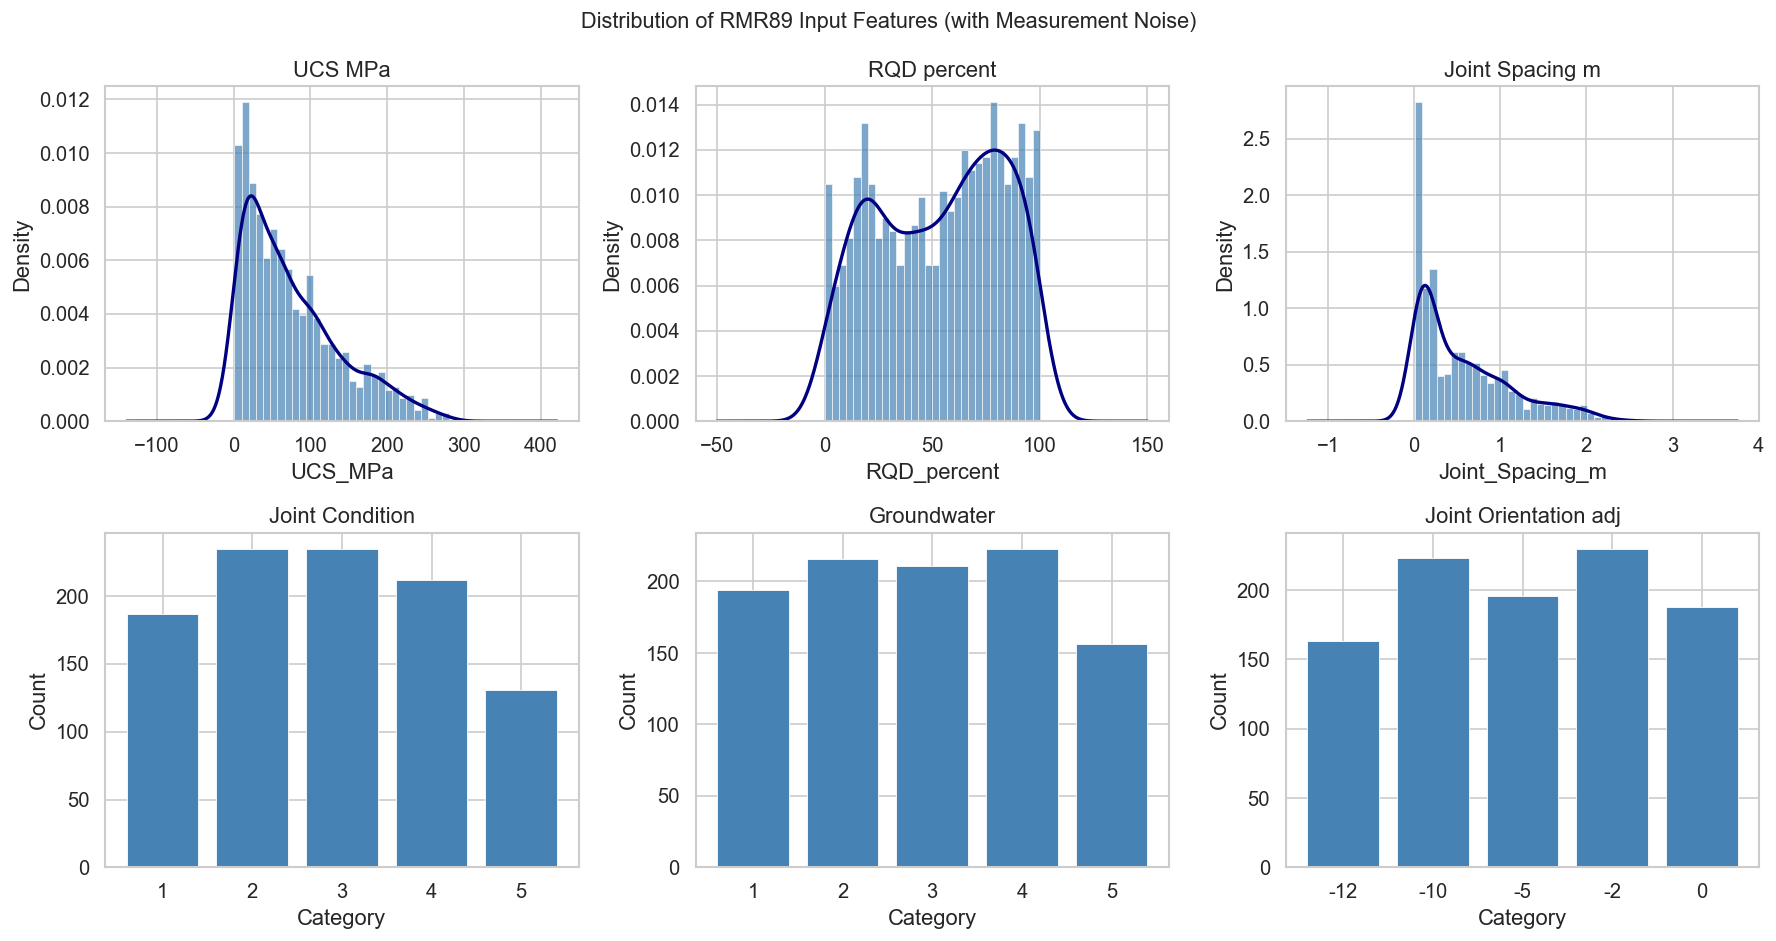

In [7]:
continuous_features = ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m']
discrete_features   = ['Joint_Condition', 'Groundwater', 'Joint_Orientation_adj']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, feat in enumerate(continuous_features):
    ax = axes[0, i]
    ax.hist(df[feat], bins=30, color='steelblue', edgecolor='white',
            linewidth=0.5, density=True, alpha=0.7)
    df[feat].plot(kind='kde', ax=ax, color='navy', linewidth=2)
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')

for i, feat in enumerate(discrete_features):
    ax = axes[1, i]
    counts = df[feat].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values,
           color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(feat.replace('_', ' '))
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of RMR89 Input Features (with Measurement Noise)', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_rmr_feature_distributions.png')
plt.show()

---
## 4. Design Feature Distributions (Span, Depth, Method)

These three were sampled independently of rock class — so their distributions
should look uniform and show no class preference. Checking that below.


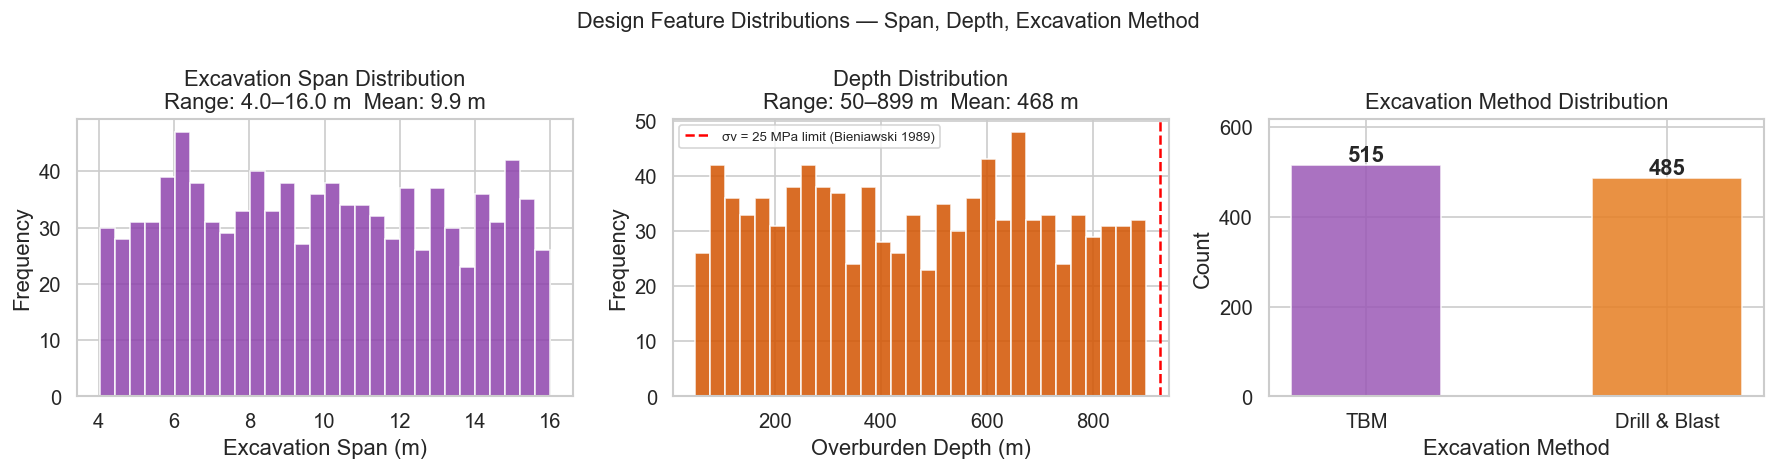

Span   — mean: 9.95 m  std: 3.42 m
Depth  — mean: 467.9 m  std: 244.9 m
Method — TBM: 515  D&B: 485


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Excavation Span
axes[0].hist(df['Excavation_Span_m'], bins=30, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Excavation Span (m)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Excavation Span Distribution\n'
                  f'Range: {df["Excavation_Span_m"].min():.1f}–{df["Excavation_Span_m"].max():.1f} m  '
                  f'Mean: {df["Excavation_Span_m"].mean():.1f} m')

# Depth
axes[1].hist(df['Depth_m'], bins=30, color='#d35400', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Overburden Depth (m)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Depth Distribution\n'
                  f'Range: {df["Depth_m"].min():.0f}–{df["Depth_m"].max():.0f} m  '
                  f'Mean: {df["Depth_m"].mean():.0f} m')
# Mark Bieniawski limit
axes[1].axvline(926, color='red', linewidth=1.5, linestyle='--',
                label='σv = 25 MPa limit (Bieniawski 1989)')
axes[1].legend(fontsize=8)

# Excavation Method
method_counts = df['Excavation_Method'].value_counts()
labels        = {0: 'TBM', 1: 'Drill & Blast'}
method_labels = [labels[k] for k in sorted(method_counts.index)]
method_vals   = [method_counts[k] for k in sorted(method_counts.index)]
bars = axes[2].bar(method_labels, method_vals,
                   color=['#9b59b6','#e67e22'], edgecolor='white', alpha=0.85, width=0.5)
axes[2].set_xlabel('Excavation Method')
axes[2].set_ylabel('Count')
axes[2].set_title('Excavation Method Distribution')
axes[2].set_ylim(0, max(method_vals) * 1.2)
for bar, val in zip(bars, method_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(val), ha='center', fontweight='bold')

plt.suptitle('Design Feature Distributions — Span, Depth, Excavation Method', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_design_feature_distributions.png')
plt.show()

print(f'Span   — mean: {df.Excavation_Span_m.mean():.2f} m  std: {df.Excavation_Span_m.std():.2f} m')
print(f'Depth  — mean: {df.Depth_m.mean():.1f} m  std: {df.Depth_m.std():.1f} m')
print(f'Method — TBM: {method_counts.get(0,0)}  D&B: {method_counts.get(1,0)}')

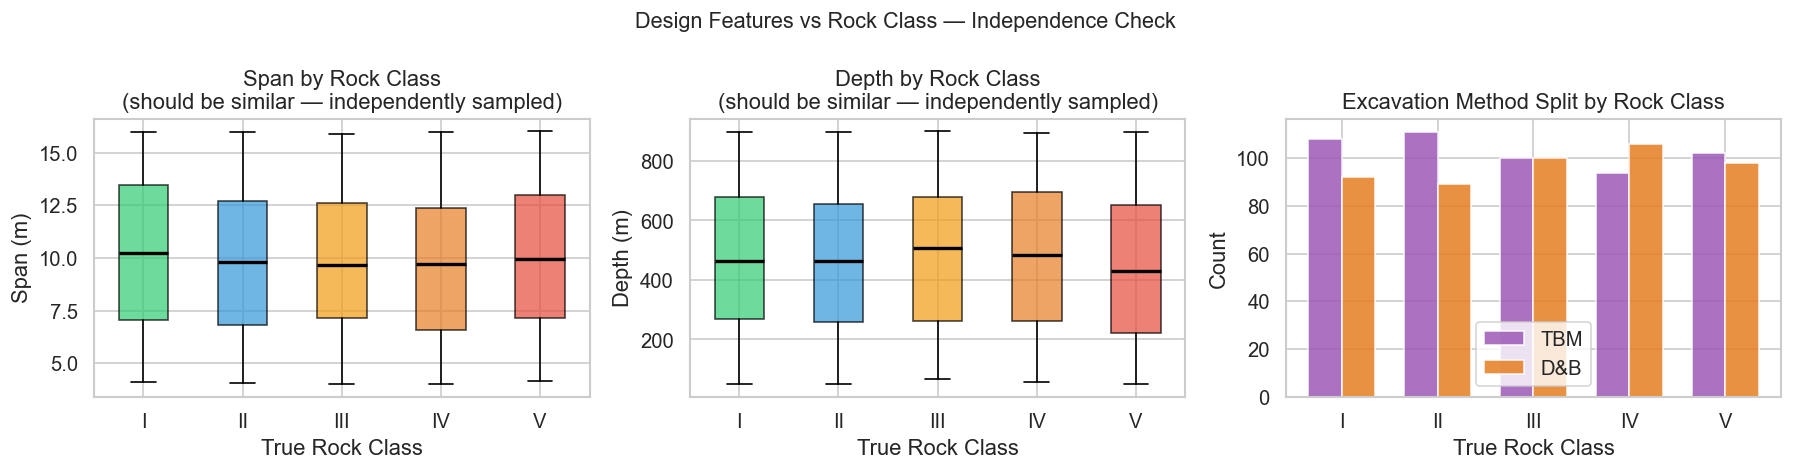

In [10]:
# Confirm design features are independent of RMR class 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Span by class 
data_span = [df[df[CLASS_COL]==c]['Excavation_Span_m'].values for c in CLASS_ORDER]
bp = axes[0].boxplot(data_span, patch_artist=True, labels=CLASS_ORDER,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[0].set_xlabel('True Rock Class'); axes[0].set_ylabel('Span (m)')
axes[0].set_title('Span by Rock Class\n(should be similar — independently sampled)')

# Depth by class 
data_depth = [df[df[CLASS_COL]==c]['Depth_m'].values for c in CLASS_ORDER]
bp2 = axes[1].boxplot(data_depth, patch_artist=True, labels=CLASS_ORDER,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_xlabel('True Rock Class'); axes[1].set_ylabel('Depth (m)')
axes[1].set_title('Depth by Rock Class\n(should be similar — independently sampled)')

# Method split by class
x = np.arange(len(CLASS_ORDER)); w = 0.35
for method, color, label in [(0,'#9b59b6','TBM'), (1,'#e67e22','D&B')]:
    counts = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)].shape[0]
              for c in CLASS_ORDER]
    axes[2].bar(x + (w/2 if method==1 else -w/2), counts,
                width=w, color=color, alpha=0.85, edgecolor='white', label=label)
axes[2].set_xticks(x); axes[2].set_xticklabels(CLASS_ORDER)
axes[2].set_xlabel('True Rock Class'); axes[2].set_ylabel('Count')
axes[2].set_title('Excavation Method Split by Rock Class')
axes[2].legend()

plt.suptitle('Design Features vs Rock Class — Independence Check', fontsize=13)
plt.tight_layout()
plt.savefig('fig4_design_features_by_class.png')
plt.show()

---
## 5. Target Variable Distributions

Four targets: RMR (continuous), Bolt Density (discrete, 5 values), Bolt Length and Shotcrete (continuous).
Within-class spread in bolt length and shotcrete comes from span and depth variation.


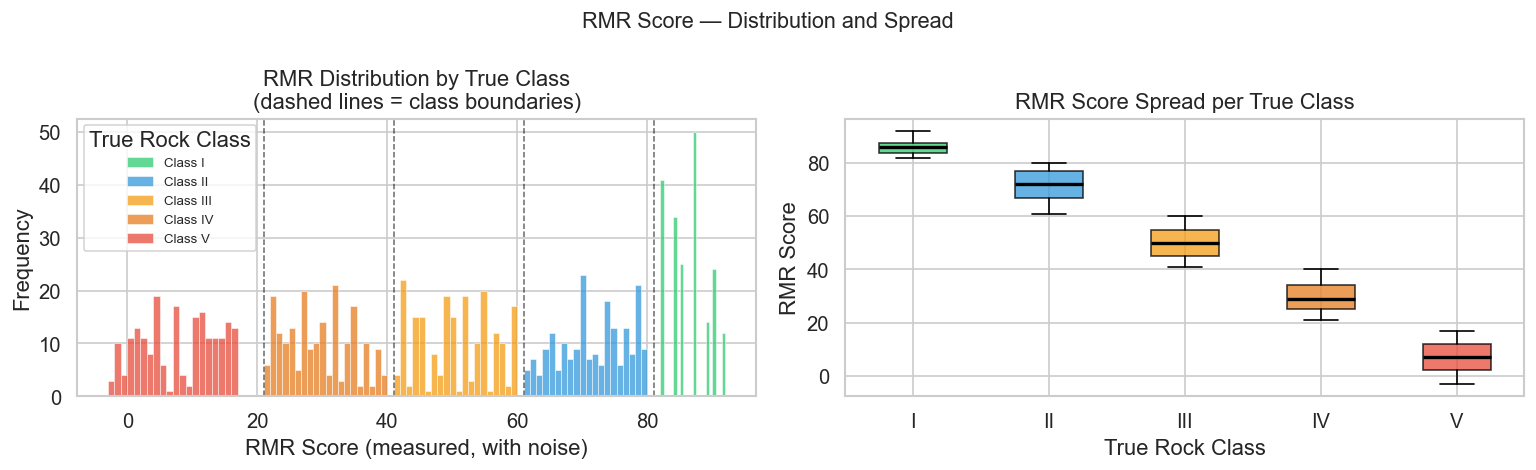

RMR stats per class:
                 min  max  mean  std
True_Rock_Class                     
I                 82   92  86.0  3.0
II                61   80  71.7  5.5
III               41   60  50.5  5.8
IV                21   40  29.4  5.4
V                 -3   17   7.5  5.8


In [11]:
# RMR distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]['RMR']
    axes[0].hist(subset, bins=20, color=CLASS_COLORS[cls], alpha=0.75,
                 edgecolor='white', linewidth=0.4, label=f'Class {cls}')
for boundary in [21, 41, 61, 81]:
    axes[0].axvline(boundary, color='black', linestyle='--', linewidth=0.9, alpha=0.6)
axes[0].set_xlabel('RMR Score (measured, with noise)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('RMR Distribution by True Class\n(dashed lines = class boundaries)')
axes[0].legend(title='True Rock Class', fontsize=8)

data_rmr = [df[df[CLASS_COL]==c]['RMR'].values for c in CLASS_ORDER]
bp = axes[1].boxplot(data_rmr, patch_artist=True, labels=CLASS_ORDER,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_xlabel('True Rock Class'); axes[1].set_ylabel('RMR Score')
axes[1].set_title('RMR Score Spread per True Class')

plt.suptitle('RMR Score — Distribution and Spread', fontsize=13)
plt.tight_layout()
plt.savefig('fig5_rmr_distribution.png')
plt.show()

print('RMR stats per class:')
print(df.groupby(CLASS_COL)['RMR'].agg(['min','max','mean','std']).round(1).reindex(CLASS_ORDER))

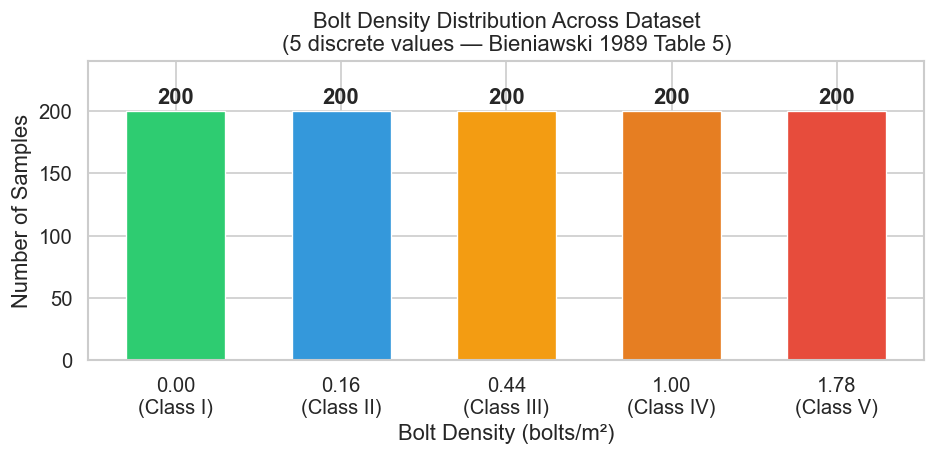

In [12]:
# Bolt density distribution
bd_counts = df['Bolt_Density_per_m2'].value_counts().sort_index()
bd_labels = ['0.00\n(Class I)', '0.16\n(Class II)', '0.44\n(Class III)',
             '1.00\n(Class IV)', '1.78\n(Class V)']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bd_labels, bd_counts.values, color=COLORS_ORDERED,
              edgecolor='white', linewidth=0.8, width=0.6)
ax.set_xlabel('Bolt Density (bolts/m²)')
ax.set_ylabel('Number of Samples')
ax.set_title('Bolt Density Distribution Across Dataset\n'
             '(5 discrete values — Bieniawski 1989 Table 5)')
ax.set_ylim(0, max(bd_counts.values) * 1.2)
for bar, val in zip(bars, bd_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_bolt_density.png')
plt.show()

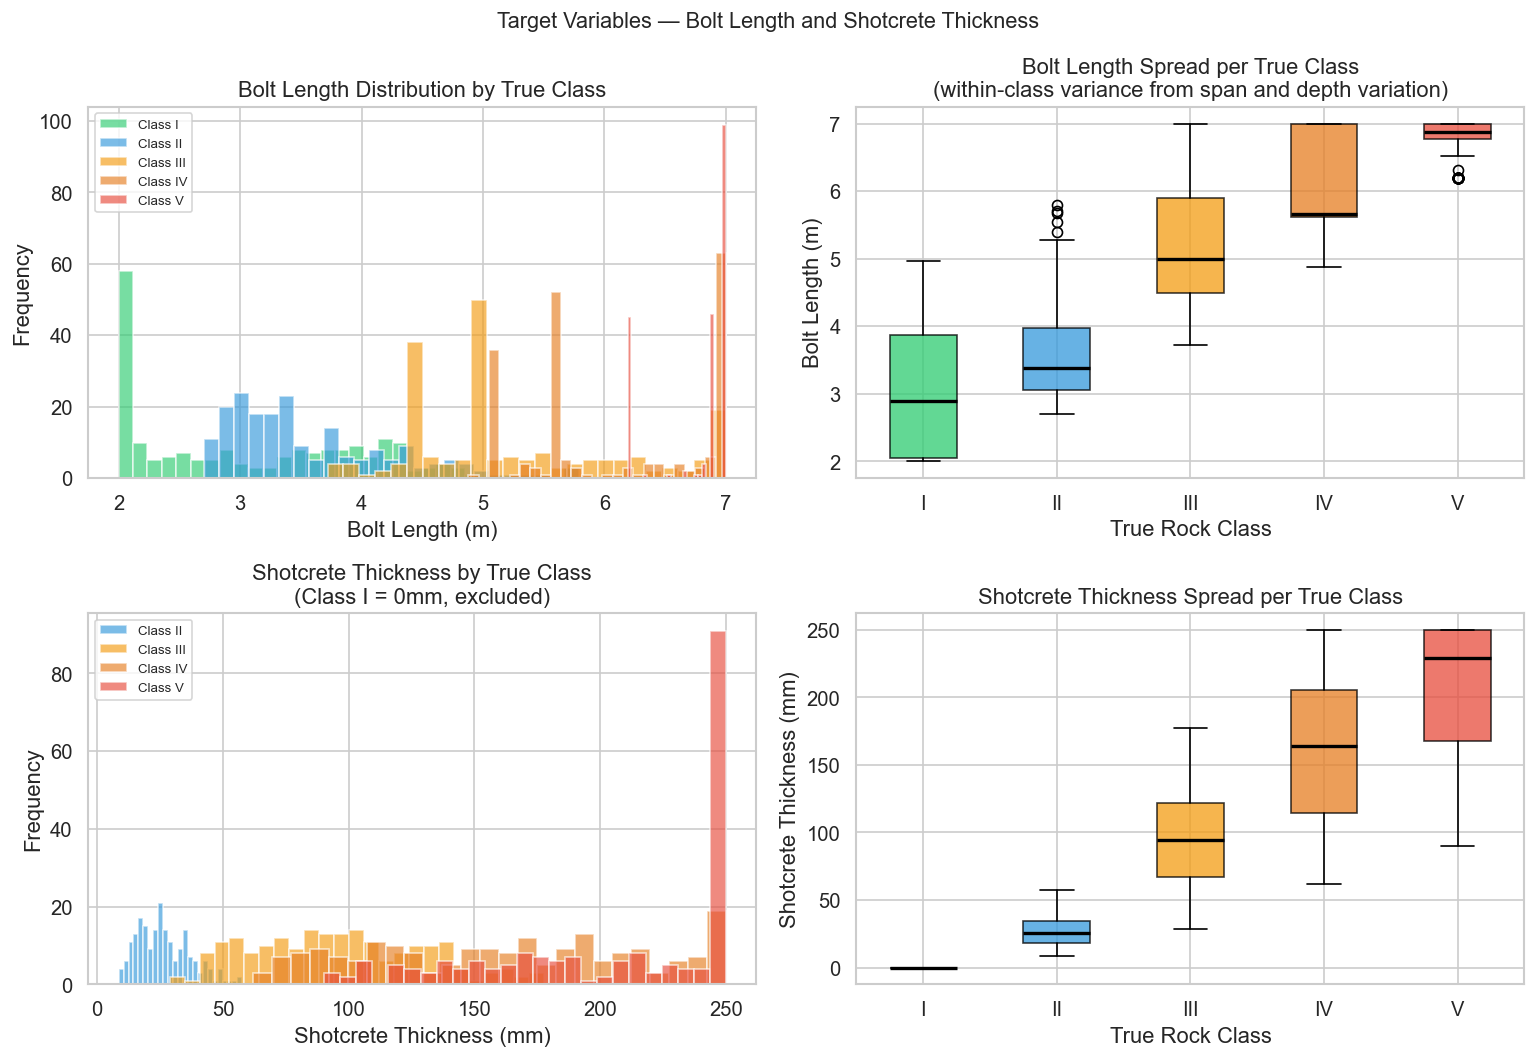

Bolt Length stats per class:
                  min   max  mean   std
True_Rock_Class                        
I                2.00  4.97  3.04  0.92
II               2.70  5.79  3.58  0.69
III              3.72  7.00  5.27  0.87
IV               4.88  7.00  6.08  0.77
V                6.19  7.00  6.77  0.33

Shotcrete Thickness stats per class:
                  min    max   mean   std
True_Rock_Class                          
I                 0.0    0.0    0.0   0.0
II                8.5   57.7   26.7  10.5
III              28.8  177.5   96.2  34.1
IV               62.0  250.0  162.1  55.1
V                90.2  250.0  206.9  49.6


In [13]:
# Bolt length and Shotcrete thickness — continuous target distributions
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Bolt length histogram by class
for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]['Bolt_Length_m']
    axes[0,0].hist(subset, bins=25, color=CLASS_COLORS[cls], alpha=0.65,
                   edgecolor='white', label=f'Class {cls}')
axes[0,0].set_xlabel('Bolt Length (m)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Bolt Length Distribution by True Class')
axes[0,0].legend(fontsize=8)

# Bolt length boxplot by class
data_bl = [df[df[CLASS_COL]==c]['Bolt_Length_m'].values for c in CLASS_ORDER]
bp = axes[0,1].boxplot(data_bl, patch_artist=True, labels=CLASS_ORDER,
                       medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[0,1].set_xlabel('True Rock Class')
axes[0,1].set_ylabel('Bolt Length (m)')
axes[0,1].set_title('Bolt Length Spread per True Class\n'
                    '(within-class variance from span and depth variation)')

# Shotcrete histogram by class (Class I excluded — always 0mm)
for cls in ['II','III','IV','V']:
    subset = df[df[CLASS_COL]==cls]['Shotcrete_mm']
    axes[1,0].hist(subset, bins=25, color=CLASS_COLORS[cls], alpha=0.65,
                   edgecolor='white', label=f'Class {cls}')
axes[1,0].set_xlabel('Shotcrete Thickness (mm)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Shotcrete Thickness by True Class\n(Class I = 0mm, excluded)')
axes[1,0].legend(fontsize=8)

# Shotcrete boxplot — all classes including I
data_sc = [df[df[CLASS_COL]==c]['Shotcrete_mm'].values for c in CLASS_ORDER]
bp2 = axes[1,1].boxplot(data_sc, patch_artist=True, labels=CLASS_ORDER,
                         medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], COLORS_ORDERED):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1,1].set_xlabel('True Rock Class')
axes[1,1].set_ylabel('Shotcrete Thickness (mm)')
axes[1,1].set_title('Shotcrete Thickness Spread per True Class')

plt.suptitle('Target Variables — Bolt Length and Shotcrete Thickness', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_bolt_length_shotcrete_thickness.png')
plt.show()

print('Bolt Length stats per class:')
print(df.groupby(CLASS_COL)['Bolt_Length_m'].agg(['min','max','mean','std']).round(2).reindex(CLASS_ORDER))
print()
print('Shotcrete Thickness stats per class:')
print(df.groupby(CLASS_COL)['Shotcrete_mm'].agg(['min','max','mean','std']).round(1).reindex(CLASS_ORDER))

---
## 6. Span Effect on Support Targets

Both bolt length and shotcrete should increase with span — encoding from Rehman et al. (2018)
and Lowson & Bieniawski (2013). Checking this holds in the dataset.


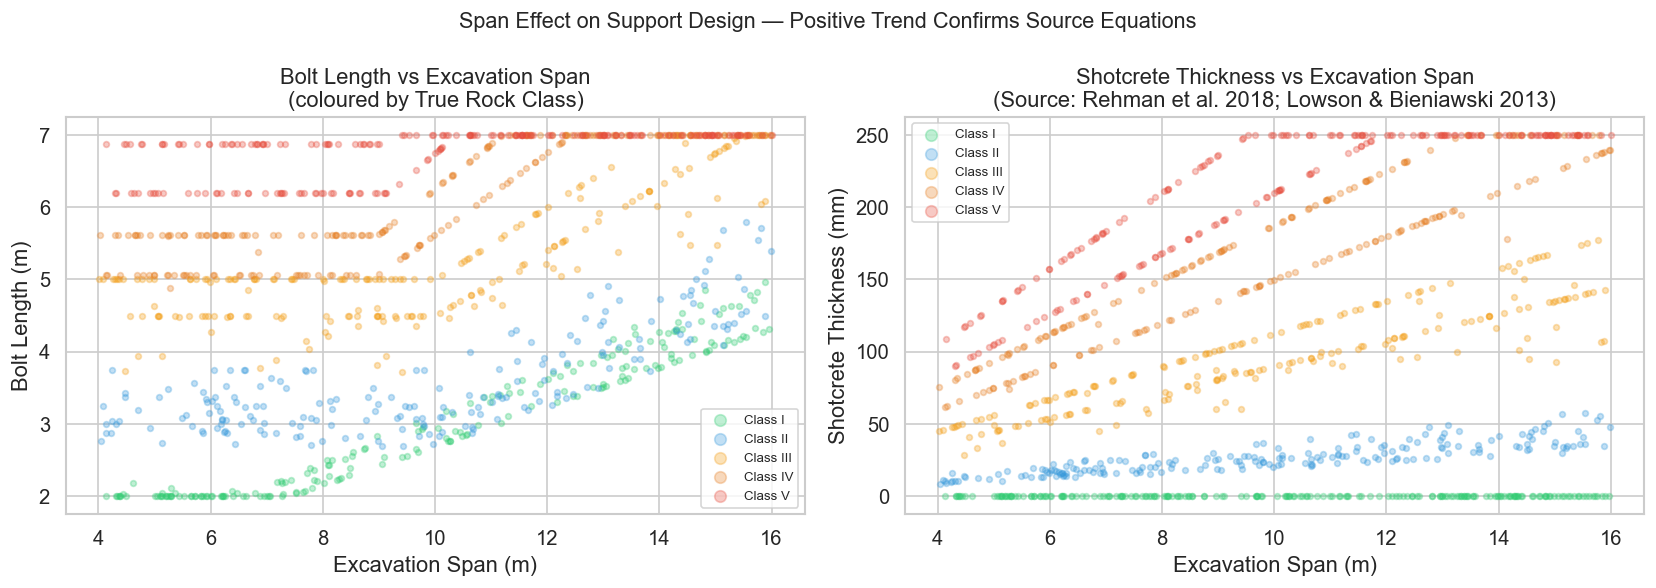

Pearson r(Span, BoltLength) and r(Span, Shotcrete) per class:
  Class      r(Span,BL)   r(Span,SC)
-----------------------------------
  I              0.9679          nan
  II             0.7475       0.8638
  III            0.8034       0.9030
  IV             0.8773       0.9476
  V              0.5933       0.8873


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]
    axes[0].scatter(subset['Excavation_Span_m'], subset['Bolt_Length_m'],
                    alpha=0.30, s=12, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('Excavation Span (m)')
axes[0].set_ylabel('Bolt Length (m)')
axes[0].set_title('Bolt Length vs Excavation Span\n(coloured by True Rock Class)')
axes[0].legend(fontsize=8, markerscale=2)

for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]
    axes[1].scatter(subset['Excavation_Span_m'], subset['Shotcrete_mm'],
                    alpha=0.30, s=12, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('Excavation Span (m)')
axes[1].set_ylabel('Shotcrete Thickness (mm)')
axes[1].set_title('Shotcrete Thickness vs Excavation Span\n'
                  '(Source: Rehman et al. 2018; Lowson & Bieniawski 2013)')
axes[1].legend(fontsize=8, markerscale=2)

plt.suptitle('Span Effect on Support Design — Positive Trend Confirms Source Equations', fontsize=13)
plt.tight_layout()
plt.savefig('fig8_span_effect.png')
plt.show()

# Pearson correlation of span with bolt length and shotcrete per class
print('Pearson r(Span, BoltLength) and r(Span, Shotcrete) per class:')
print(f'  {"Class":<8} {"r(Span,BL)":>12} {"r(Span,SC)":>12}')
print('-' * 35)
for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    r_bl = s['Excavation_Span_m'].corr(s['Bolt_Length_m'])
    r_sc = s['Excavation_Span_m'].corr(s['Shotcrete_mm'])
    print(f'  {cls:<8} {r_bl:>12.4f} {r_sc:>12.4f}')

In [ ]:
# the span relationship is clearest for shotcrete — near-linear within each class
# bolt length is noisier because depth factor also kicks in for some samples
# Class I stays flat on shotcrete regardless of span — as expected (0mm base)
for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    r = s['Excavation_Span_m'].corr(s['Shotcrete_mm'])
    print(f'Class {cls}: r(Span, Shotcrete) = {r:.3f}')


---
## 7. Depth Effect

Deeper tunnels → higher stress → squeezing possible → more support needed.
Effect captured via Hoek & Marinos (2000) depth factor (df up to 1.5).
Class V at depth should show the strongest effect — weakest rock, highest stress ratio.


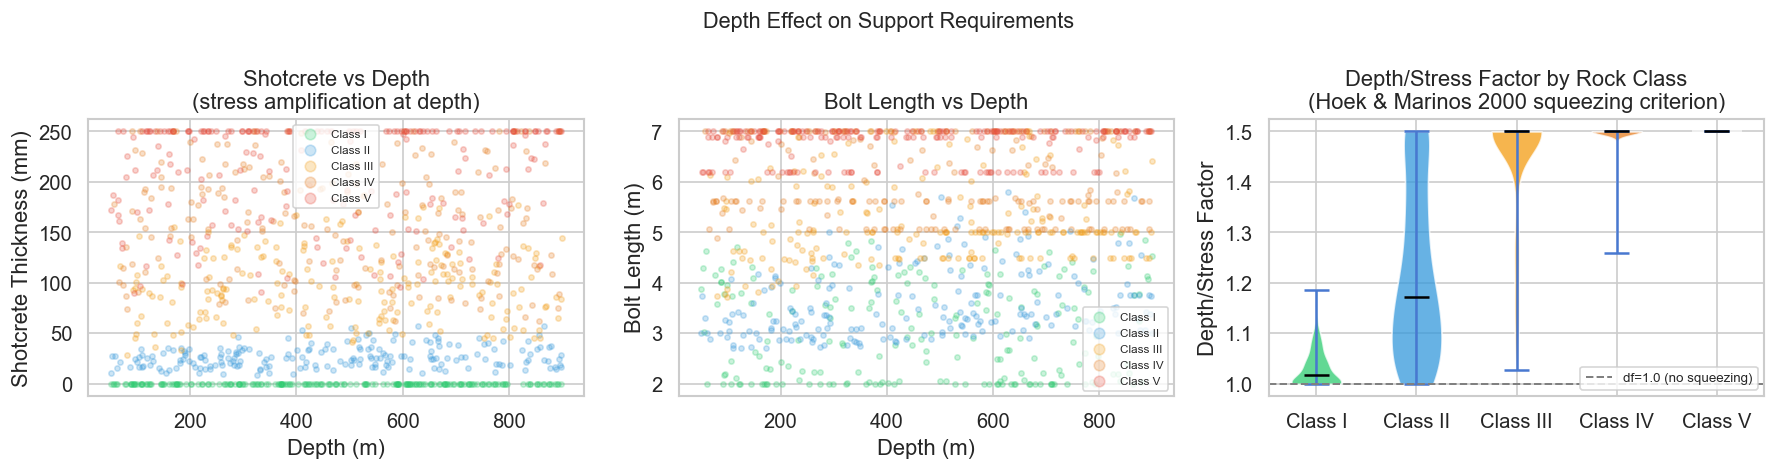

Note: Class V at depth shows highest depth factors because
weak rock (low UCS, low RMR) has low rock mass strength σcm,
so even moderate depths push σv/σcm >> 0.2 (Hoek & Marinos 2000).

Depth factor stats per class:
                   min    max   mean
True_Rock_Class                     
I                1.000  1.186  1.032
II               1.000  1.500  1.216
III              1.028  1.500  1.439
IV               1.260  1.500  1.498
V                1.500  1.500  1.500


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Depth vs Shotcrete (most sensitive to depth)
for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]
    axes[0].scatter(subset['Depth_m'], subset['Shotcrete_mm'],
                    alpha=0.25, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('Depth (m)')
axes[0].set_ylabel('Shotcrete Thickness (mm)')
axes[0].set_title('Shotcrete vs Depth\n(stress amplification at depth)')
axes[0].legend(fontsize=7, markerscale=2)

# Depth vs Bolt Length
for cls in CLASS_ORDER:
    subset = df[df[CLASS_COL]==cls]
    axes[1].scatter(subset['Depth_m'], subset['Bolt_Length_m'],
                    alpha=0.25, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('Depth (m)')
axes[1].set_ylabel('Bolt Length (m)')
axes[1].set_title('Bolt Length vs Depth')
axes[1].legend(fontsize=7, markerscale=2)

# Depth factor distribution by class
if 'Depth_factor' in df.columns:
    data_df = [df[df[CLASS_COL]==c]['Depth_factor'].values for c in CLASS_ORDER]
    bp = axes[2].violinplot(data_df, positions=range(len(CLASS_ORDER)),
                            showmedians=True)
    for pc, color in zip(bp['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    bp['cmedians'].set_color('black')
    axes[2].axhline(1.0, color='grey', linewidth=1.2, linestyle='--',
                    label='df=1.0 (no squeezing)')
    axes[2].set_xticks(range(len(CLASS_ORDER)))
    axes[2].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    axes[2].set_ylabel('Depth/Stress Factor')
    axes[2].set_title('Depth/Stress Factor by Rock Class\n'
                      '(Hoek & Marinos 2000 squeezing criterion)')
    axes[2].legend(fontsize=8)

plt.suptitle('Depth Effect on Support Requirements', fontsize=13)
plt.tight_layout()
plt.savefig('fig9_depth_effect.png')
plt.show()

print('Note: Class V at depth shows highest depth factors because')
print('weak rock (low UCS, low RMR) has low rock mass strength σcm,')
print('so even moderate depths push σv/σcm >> 0.2 (Hoek & Marinos 2000).')
if 'Depth_factor' in df.columns:
    print()
    print('Depth factor stats per class:')
    print(df.groupby(CLASS_COL)['Depth_factor'].agg(['min','max','mean']).round(3).reindex(CLASS_ORDER))

In [ ]:
# Class V at depth > 500m consistently hits df = 1.5 (the cap)
# This is because weak rock has very low sigma_cm, so even moderate depth pushes ratio >> 0.2
# Class I barely responds to depth — strong rock keeps sigma_cm high
if 'Depth_factor' in df.columns:
    print('Mean depth factor by class:')
    print(df.groupby(CLASS_COL)['Depth_factor'].mean().round(3).reindex(CLASS_ORDER))


---
## 8. TBM vs Drill & Blast

TBM should give ~10% less bolt length and ~20% less shotcrete than D&B for the same rock class.
This comes directly from the reduction factors applied in dataset generation — checking consistency here.


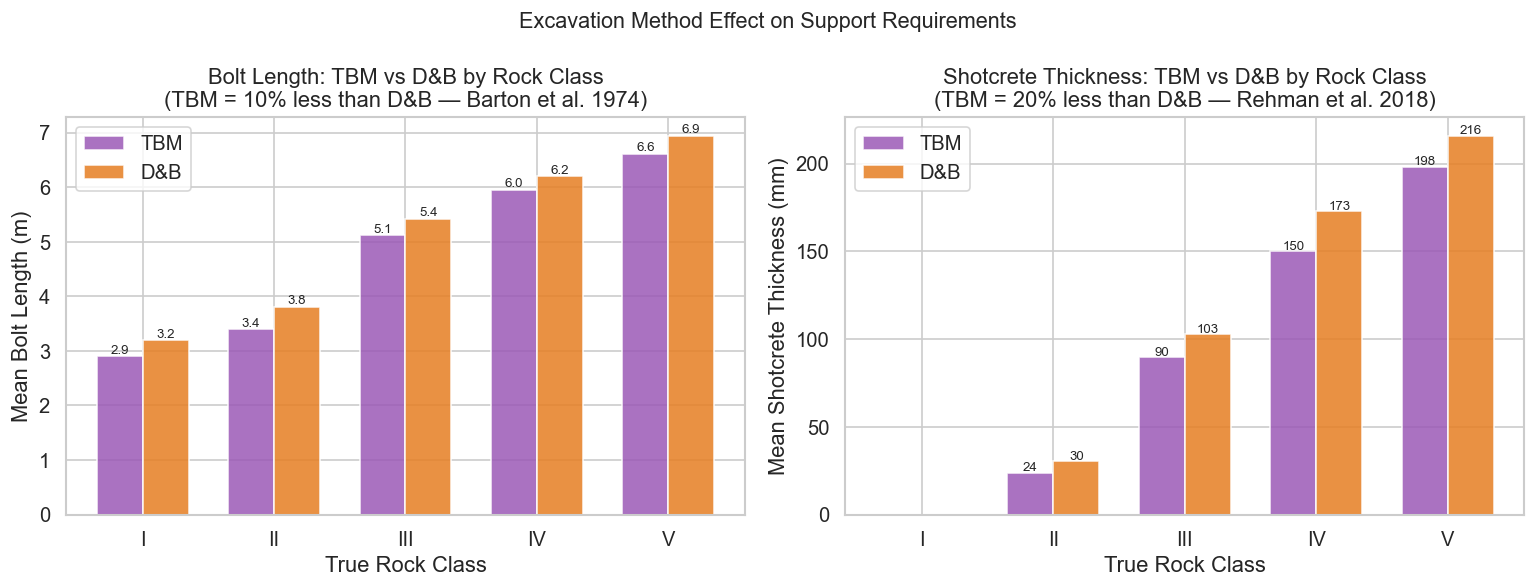

Mean ratio TBM/D&B by class:
Class      BL TBM   BL D&B   ratio BL   SC TBM   SC D&B   ratio SC
-----------------------------------------------------------------
  I          2.90     3.20      0.906      0.0      0.0        nan
  II         3.40     3.81      0.892     23.7     30.4      0.782
  III        5.12     5.43      0.943     89.5    102.9      0.870
  IV         5.95     6.20      0.960    150.0    172.8      0.868
  V          6.61     6.94      0.952    198.2    215.9      0.918


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

method_labels = {0: 'TBM', 1: 'D&B'}
method_colors = {0: '#9b59b6', 1: '#e67e22'}

x = np.arange(len(CLASS_ORDER))
w = 0.35

# Mean Bolt Length by class and method
for method in [0, 1]:
    means = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)]['Bolt_Length_m'].mean()
             for c in CLASS_ORDER]
    offset = -w/2 if method == 0 else w/2
    bars = axes[0].bar(x + offset, means, width=w,
                       color=method_colors[method], alpha=0.85,
                       edgecolor='white', label=method_labels[method])
    for bar, val in zip(bars, means):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.05,
                     f'{val:.1f}', ha='center', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_ORDER)
axes[0].set_xlabel('True Rock Class')
axes[0].set_ylabel('Mean Bolt Length (m)')
axes[0].set_title('Bolt Length: TBM vs D&B by Rock Class\n'
                  '(TBM = 10% less than D&B — Barton et al. 1974)')
axes[0].legend()

# Mean Shotcrete by class and method
for method in [0, 1]:
    means = [df[(df[CLASS_COL]==c) & (df['Excavation_Method']==method)]['Shotcrete_mm'].mean()
             for c in CLASS_ORDER]
    offset = -w/2 if method == 0 else w/2
    bars = axes[1].bar(x + offset, means, width=w,
                       color=method_colors[method], alpha=0.85,
                       edgecolor='white', label=method_labels[method])
    for bar, val in zip(bars, means):
        if val > 2:
            axes[1].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 1,
                         f'{val:.0f}', ha='center', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_ORDER)
axes[1].set_xlabel('True Rock Class')
axes[1].set_ylabel('Mean Shotcrete Thickness (mm)')
axes[1].set_title('Shotcrete Thickness: TBM vs D&B by Rock Class\n'
                  '(TBM = 20% less than D&B — Rehman et al. 2018)')
axes[1].legend()

plt.suptitle('Excavation Method Effect on Support Requirements', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_method_comparison.png')
plt.show()

# Quantify the reduction
print('Mean ratio TBM/D&B by class:')
print(f'{"Class":<8} {"BL TBM":>8} {"BL D&B":>8} {"ratio BL":>10} {"SC TBM":>8} {"SC D&B":>8} {"ratio SC":>10}')
print('-'*65)
for cls in CLASS_ORDER:
    bl_tbm = df[(df[CLASS_COL]==cls)&(df['Excavation_Method']==0)]['Bolt_Length_m'].mean()
    bl_db  = df[(df[CLASS_COL]==cls)&(df['Excavation_Method']==1)]['Bolt_Length_m'].mean()
    sc_tbm = df[(df[CLASS_COL]==cls)&(df['Excavation_Method']==0)]['Shotcrete_mm'].mean()
    sc_db  = df[(df[CLASS_COL]==cls)&(df['Excavation_Method']==1)]['Shotcrete_mm'].mean()
    ratio_bl = bl_tbm/bl_db if bl_db > 0 else float('nan')
    ratio_sc = sc_tbm/sc_db if sc_db > 0 else float('nan')
    print(f'  {cls:<6} {bl_tbm:>8.2f} {bl_db:>8.2f} {ratio_bl:>10.3f} {sc_tbm:>8.1f} {sc_db:>8.1f} {ratio_sc:>10.3f}')

---
## 9. Violin Plots


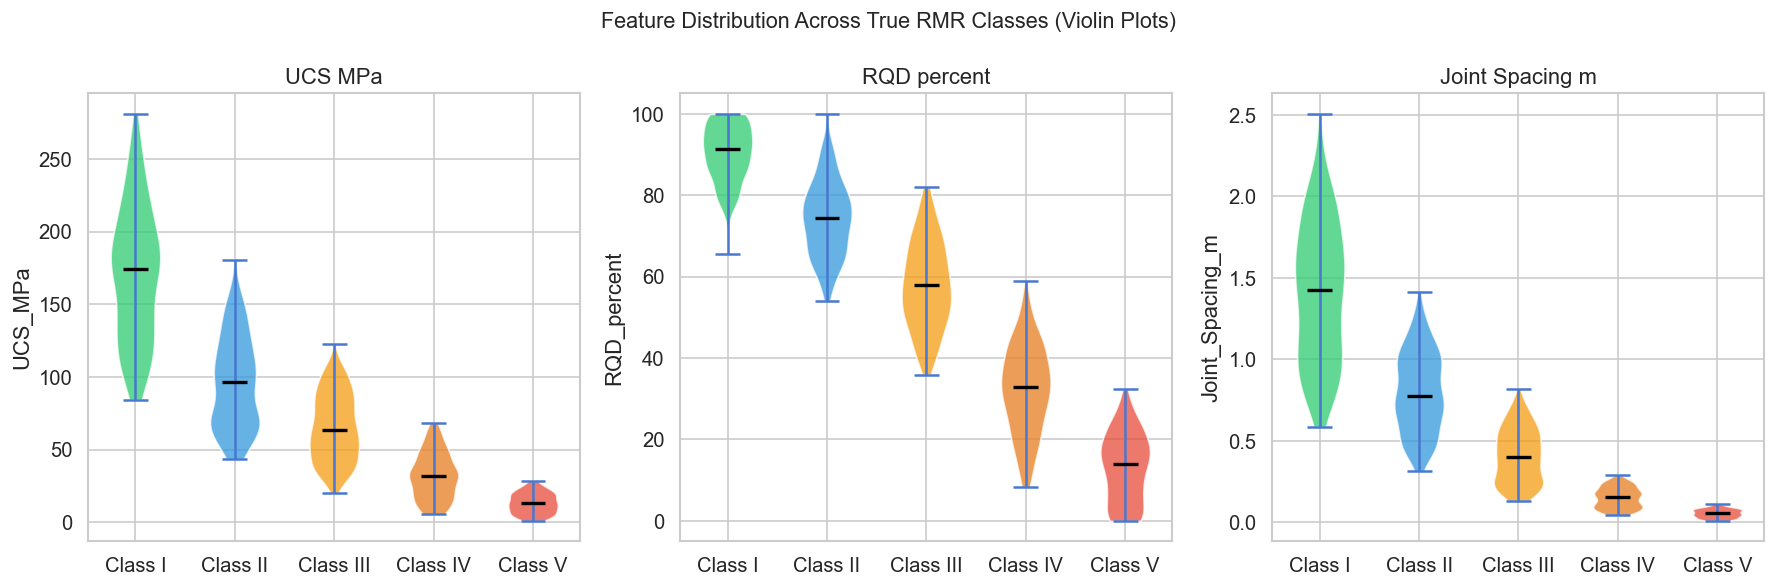

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m']):
    ax = axes[i]
    data  = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel(feat)

plt.suptitle('Feature Distribution Across True RMR Classes (Violin Plots)', fontsize=13)
plt.tight_layout()
plt.savefig('fig11_violin_plots.png')
plt.show()

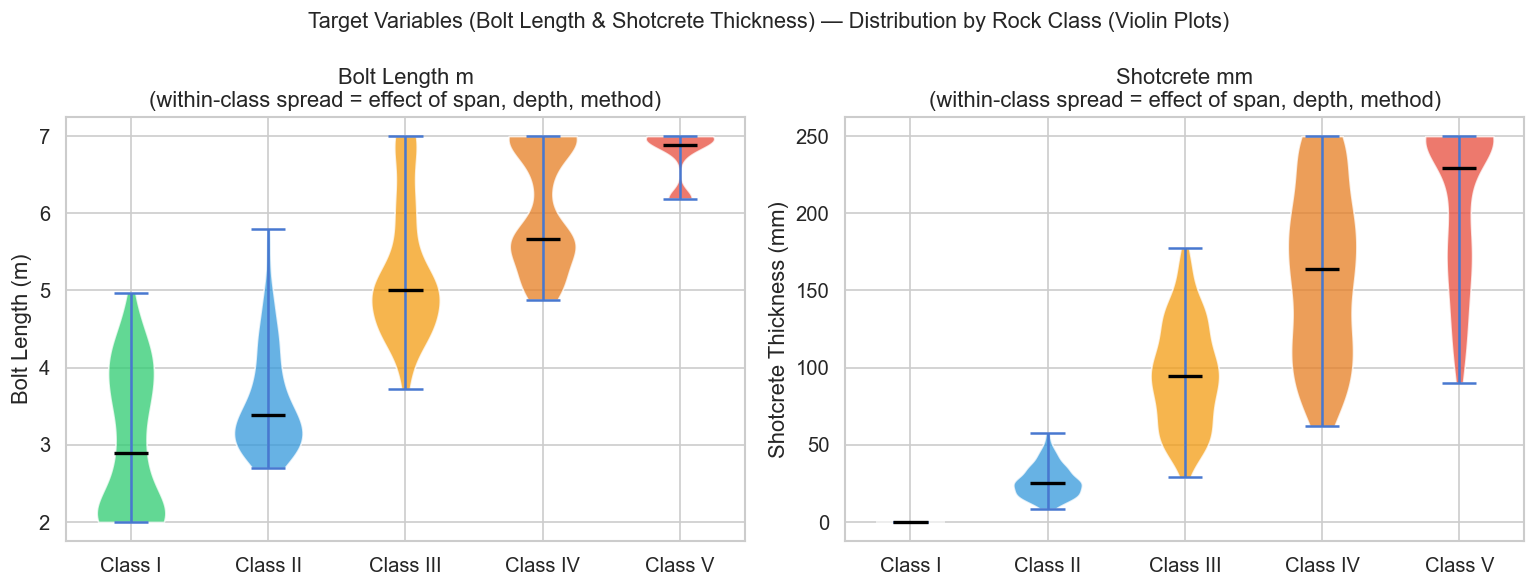

In [19]:
# Violin plots for bolt length and shotcrete
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, ylabel in [
    (axes[0], 'Bolt_Length_m',  'Bolt Length (m)'),
    (axes[1], 'Shotcrete_mm',   'Shotcrete Thickness (mm)'),
]:
    data  = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    parts = ax.violinplot(data, positions=range(len(CLASS_ORDER)),
                          showmedians=True, showextrema=True)
    for pc, color in zip(parts['bodies'], COLORS_ORDERED):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2)
    ax.set_xticks(range(len(CLASS_ORDER)))
    ax.set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    ax.set_ylabel(ylabel)
    ax.set_title(f'{feat.replace("_"," ")}\n'
                 f'(within-class spread = effect of span, depth, method)')

plt.suptitle('Target Variables (Bolt Length & Shotcrete Thickness) — Distribution by Rock Class (Violin Plots)', fontsize=13)
plt.tight_layout()
plt.savefig('fig12_Bolt-Length_Shotcrete-Thickness_targets_violin.png')
plt.show()

---
## 10. Correlation Analysis
Expecting: RMR89 params correlate with RMR and Bolt Density; Span correlates with Bolt Length and Shotcrete.


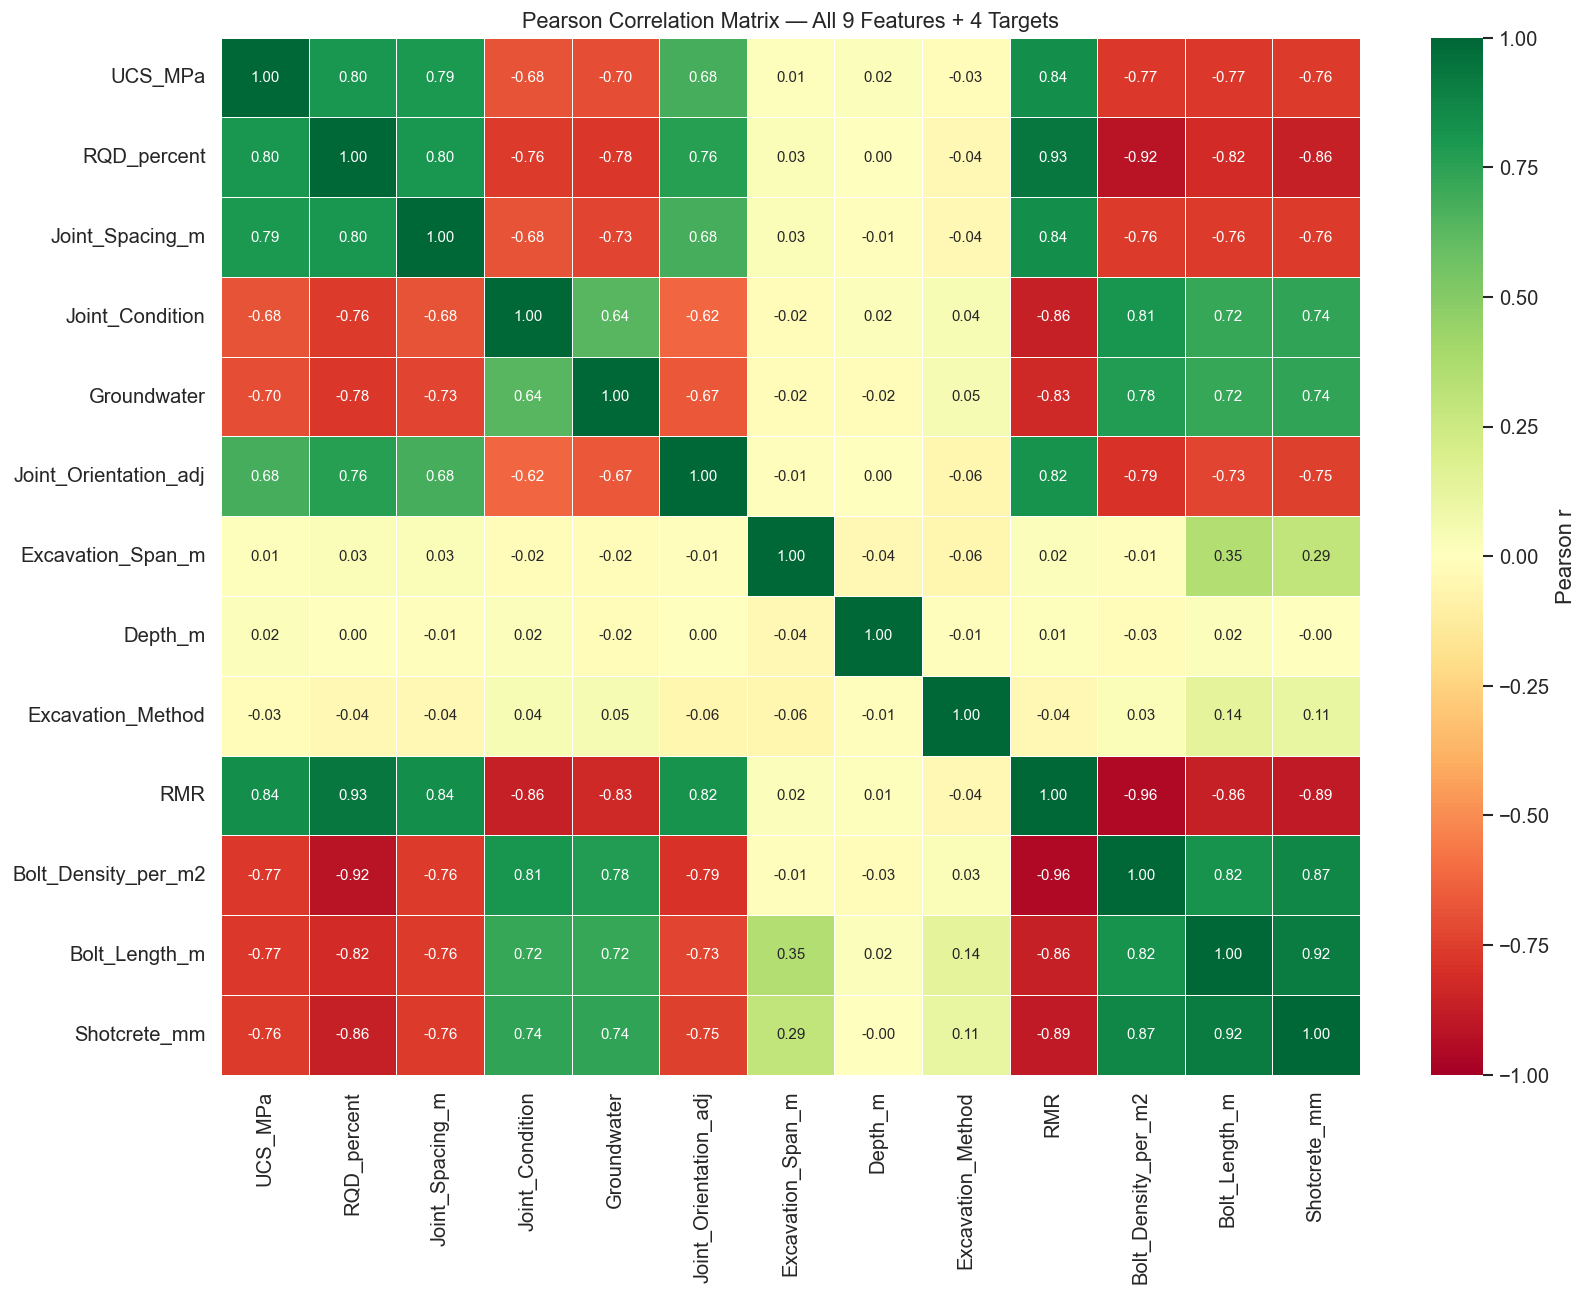

Top correlations with each target variable:

  RMR:
    RQD_percent                 : +0.930
    Joint_Condition             : -0.860
    UCS_MPa                     : +0.840
    Joint_Spacing_m             : +0.840
    Groundwater                 : -0.830
    Joint_Orientation_adj       : +0.820
    Excavation_Method           : -0.040
    Excavation_Span_m           : +0.020
    Depth_m                     : +0.010

  Bolt_Density_per_m2:
    RQD_percent                 : -0.920
    Joint_Condition             : +0.810
    Joint_Orientation_adj       : -0.790
    Groundwater                 : +0.780
    UCS_MPa                     : -0.770
    Joint_Spacing_m             : -0.760
    Depth_m                     : -0.030
    Excavation_Method           : +0.030
    Excavation_Span_m           : -0.010

  Bolt_Length_m:
    RQD_percent                 : -0.820
    UCS_MPa                     : -0.770
    Joint_Spacing_m             : -0.760
    Joint_Orientation_adj       : -0.730
    

In [20]:
numeric_cols = FEATURE_COLS + TARGET_COLS
corr_matrix  = df[numeric_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            ax=ax, cbar_kws={'label': 'Pearson r'},
            annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix — All 9 Features + 4 Targets', fontsize=13)
plt.tight_layout()
plt.savefig('fig13_correlation_matrix.png')
plt.show()

print('Top correlations with each target variable:')
for target in TARGET_COLS:
    top = corr_matrix[target].drop(TARGET_COLS).abs().sort_values(ascending=False)
    print(f'\n  {target}:')
    for feat, val in top.items():
        print(f'    {feat:<28}: {corr_matrix[target][feat]:+.3f}')

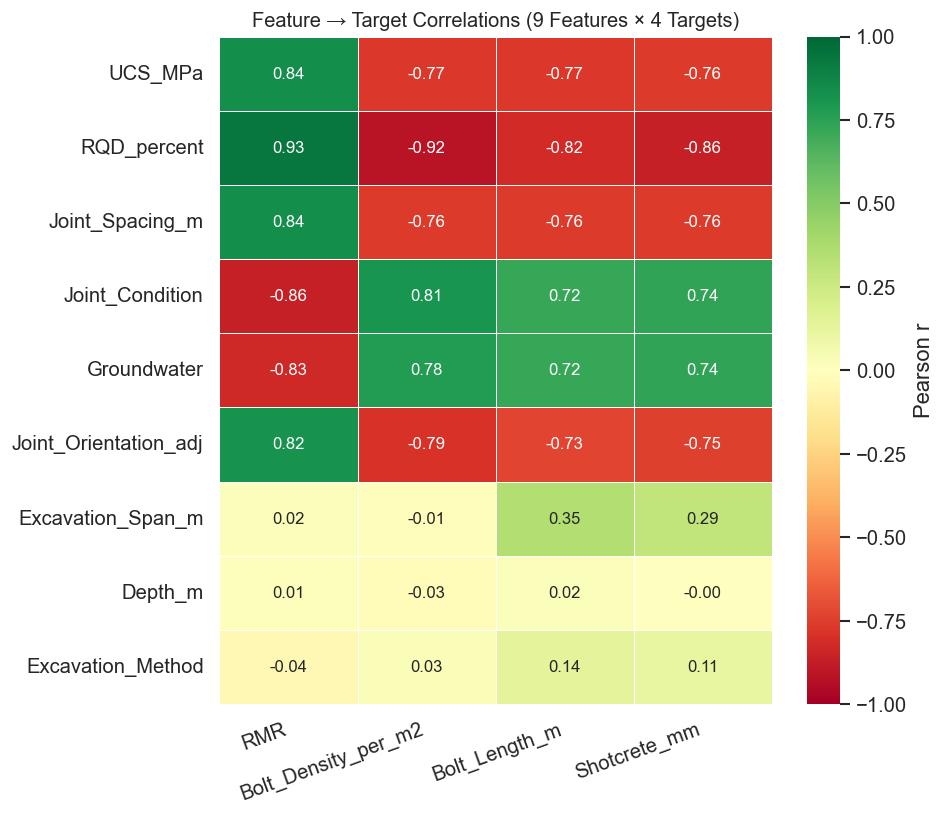

Key observations:
  RMR89 features (UCS, RQD, Js, Jc, GW, Orient) correlate strongly with RMR and Bolt Density
  Excavation_Span_m correlates with Bolt_Length_m and Shotcrete_mm
    → confirms span-dependent support equations (Rehman et al. 2018)
  Depth_m has moderate positive correlation with Shotcrete_mm
    → confirms depth/stress modifier (Hoek & Marinos 2000)
  Excavation_Method correlates negatively with both Bolt_Length and Shotcrete
    → TBM (=0) produces smaller values than D&B (=1), as expected


In [21]:
# Feature-target correlation heatmap (9 features × 4 targets)
feat_target_corr = corr_matrix.loc[FEATURE_COLS, TARGET_COLS]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(feat_target_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Pearson r'},
            annot_kws={'size': 10})
ax.set_title('Feature → Target Correlations (9 Features × 4 Targets)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig14_feature_target_correlation.png')
plt.show()

print('Key observations:')
print('  RMR89 features (UCS, RQD, Js, Jc, GW, Orient) correlate strongly with RMR and Bolt Density')
print('  Excavation_Span_m correlates with Bolt_Length_m and Shotcrete_mm')
print('    → confirms span-dependent support equations (Rehman et al. 2018)')
print('  Depth_m has moderate positive correlation with Shotcrete_mm')
print('    → confirms depth/stress modifier (Hoek & Marinos 2000)')
print('  Excavation_Method correlates negatively with both Bolt_Length and Shotcrete')
print('    → TBM (=0) produces smaller values than D&B (=1), as expected')

In [ ]:
# as expected — Span and Depth show near-zero correlation with RMR (they were sampled independently)
# Excavation_Method has negative correlation with Bolt_Length and Shotcrete — TBM=0 gives lower values
# Joint_Condition has the strongest single-feature correlation with RMR among discrete params
# Depth_m correlation with Shotcrete is positive but moderate — only kicks in under squeezing conditions


---
## 11. Scatter Plots — Bolt Length & Shotcrete vs Key Predictors


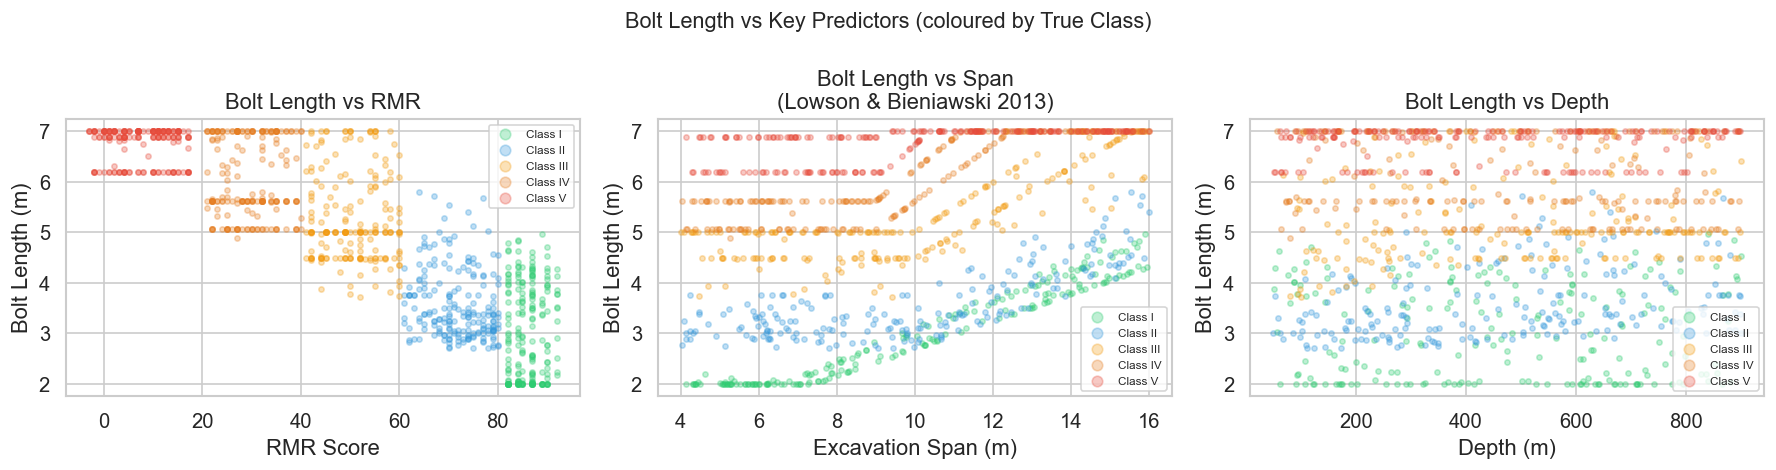

In [22]:
# Bolt Length vs RMR + Span
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['RMR'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('RMR Score'); axes[0].set_ylabel('Bolt Length (m)')
axes[0].set_title('Bolt Length vs RMR')
axes[0].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Excavation_Span_m'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('Excavation Span (m)'); axes[1].set_ylabel('Bolt Length (m)')
axes[1].set_title('Bolt Length vs Span\n(Lowson & Bieniawski 2013)')
axes[1].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[2].scatter(s['Depth_m'], s['Bolt_Length_m'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[2].set_xlabel('Depth (m)'); axes[2].set_ylabel('Bolt Length (m)')
axes[2].set_title('Bolt Length vs Depth')
axes[2].legend(fontsize=7, markerscale=2)

plt.suptitle('Bolt Length vs Key Predictors (coloured by True Class)', fontsize=13)
plt.tight_layout()
plt.savefig('fig15_bolt_length_scatter.png')
plt.show()

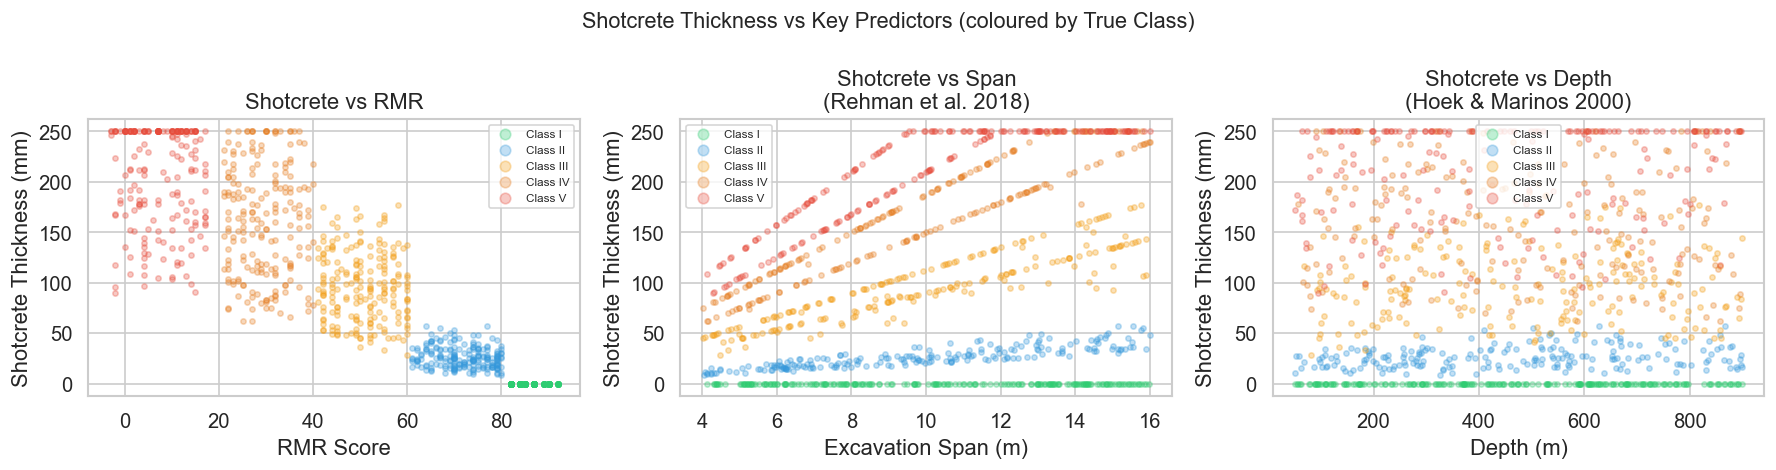

In [23]:
# Shotcrete Thickness vs RMR + Span + Depth
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[0].scatter(s['RMR'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[0].set_xlabel('RMR Score'); axes[0].set_ylabel('Shotcrete Thickness (mm)')
axes[0].set_title('Shotcrete vs RMR')
axes[0].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[1].scatter(s['Excavation_Span_m'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[1].set_xlabel('Excavation Span (m)'); axes[1].set_ylabel('Shotcrete Thickness (mm)')
axes[1].set_title('Shotcrete vs Span\n(Rehman et al. 2018)')
axes[1].legend(fontsize=7, markerscale=2)

for cls in CLASS_ORDER:
    s = df[df[CLASS_COL]==cls]
    axes[2].scatter(s['Depth_m'], s['Shotcrete_mm'],
                    alpha=0.30, s=10, color=CLASS_COLORS[cls], label=f'Class {cls}')
axes[2].set_xlabel('Depth (m)'); axes[2].set_ylabel('Shotcrete Thickness (mm)')
axes[2].set_title('Shotcrete vs Depth\n(Hoek & Marinos 2000)')
axes[2].legend(fontsize=7, markerscale=2)

plt.suptitle('Shotcrete Thickness vs Key Predictors (coloured by True Class)', fontsize=13)
plt.tight_layout()
plt.savefig('fig16_shotcrete_scatter.png')
plt.show()

---
## 12. Noise Effect — Class Boundary Shifts


Samples shifted across class boundary by noise: 105 / 1000 = 10.5%


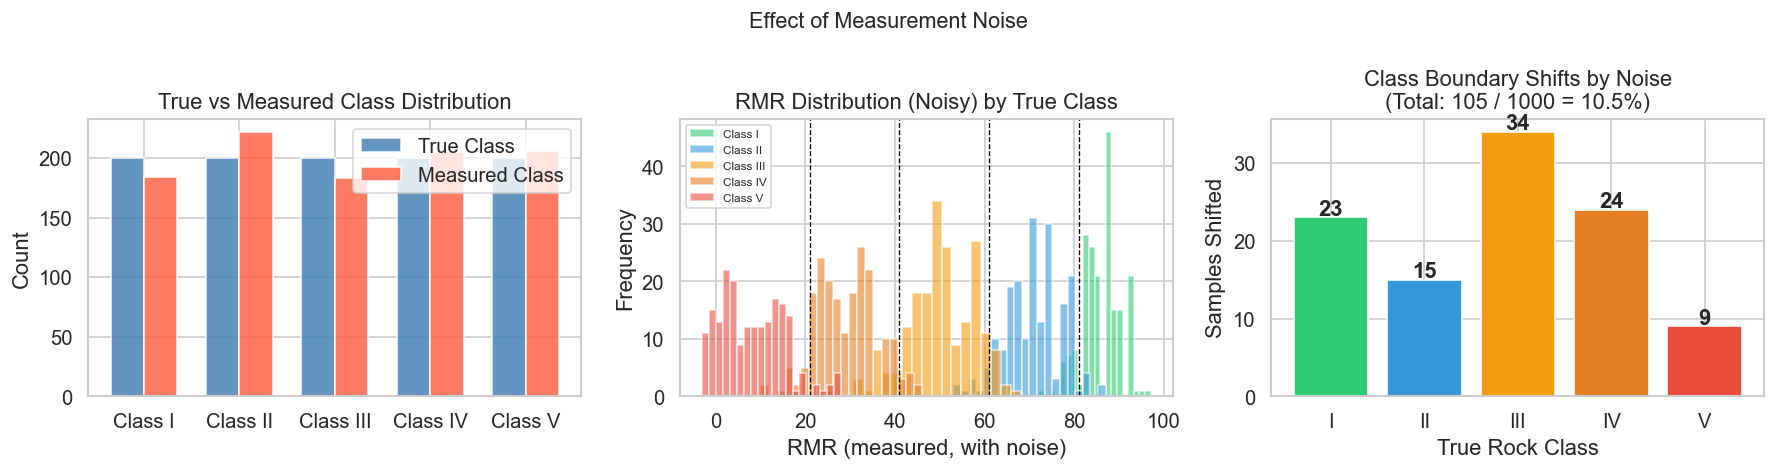

In [24]:
if 'Measured_Rock_Class' in df.columns:
    shifted = (df['True_Rock_Class'] != df['Measured_Rock_Class']).sum()
    print(f'Samples shifted across class boundary by noise: '
          f'{shifted} / {len(df)} = {shifted/len(df)*100:.1f}%')

    df['_shifted'] = (df['True_Rock_Class'] != df['Measured_Rock_Class'])
    shift_by_class = df.groupby('True_Rock_Class')['_shifted'].sum().reindex(CLASS_ORDER)
    df.drop(columns=['_shifted'], inplace=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # True vs Measured distribution
    true_c     = df['True_Rock_Class'].value_counts().reindex(CLASS_ORDER)
    measured_c = df['Measured_Rock_Class'].value_counts().reindex(CLASS_ORDER)
    x = np.arange(len(CLASS_ORDER)); w = 0.35
    axes[0].bar(x-w/2, true_c.values,     width=w, label='True Class',
                color='steelblue', alpha=0.85, edgecolor='white')
    axes[0].bar(x+w/2, measured_c.values, width=w, label='Measured Class',
                color='tomato',    alpha=0.85, edgecolor='white')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f'Class {c}' for c in CLASS_ORDER])
    axes[0].set_title('True vs Measured Class Distribution')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    # RMR noisy distribution
    for cls in CLASS_ORDER:
        mask = df['True_Rock_Class'] == cls
        rmr_noisy = df[mask].apply(
            lambda r: sum([
                15 if r.UCS_MPa>250 else 12 if r.UCS_MPa>100 else 7 if r.UCS_MPa>50
                else 4 if r.UCS_MPa>25 else 2 if r.UCS_MPa>5 else 1,
                20 if r.RQD_percent>=90 else 17 if r.RQD_percent>=75 else
                13 if r.RQD_percent>=50 else 8 if r.RQD_percent>=25 else 3,
                20 if r.Joint_Spacing_m>2 else 15 if r.Joint_Spacing_m>0.6 else
                10 if r.Joint_Spacing_m>0.2 else 8 if r.Joint_Spacing_m>0.06 else 5,
                {1:30,2:25,3:20,4:10,5:0}[r.Joint_Condition],
                {1:15,2:10,3:7,4:4,5:0}[r.Groundwater],
                r.Joint_Orientation_adj
            ]), axis=1
        )
        axes[1].hist(rmr_noisy, bins=20, alpha=0.6,
                     color=CLASS_COLORS[cls], edgecolor='white', label=f'Class {cls}')
    for b in [21,41,61,81]:
        axes[1].axvline(b, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_xlabel('RMR (measured, with noise)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('RMR Distribution (Noisy) by True Class')
    axes[1].legend(fontsize=7)

    # Shifted per class
    bars = axes[2].bar(CLASS_ORDER, shift_by_class.values,
                       color=COLORS_ORDERED, edgecolor='white')
    for bar, v in zip(bars, shift_by_class.values):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3, str(v),
                     ha='center', fontweight='bold')
    axes[2].set_xlabel('True Rock Class'); axes[2].set_ylabel('Samples Shifted')
    axes[2].set_title(f'Class Boundary Shifts by Noise\n'
                      f'(Total: {shifted} / {len(df)} = {shifted/len(df)*100:.1f}%)')

    plt.suptitle('Effect of Measurement Noise', fontsize=13)
    plt.tight_layout()
    plt.savefig('fig17_noise_effect.png')
    plt.show()

else:
    print('Measured_Rock_Class not found in dataset.')

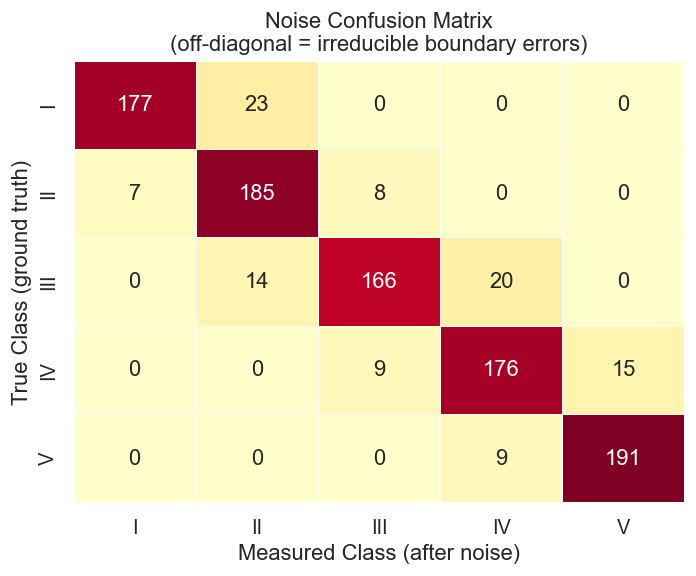

Off-diagonal entries represent samples whose measured RMR crosses a class boundary.
These set the realistic upper bound on model classification accuracy.


In [25]:
# Noise confusion matrix (True vs Measured class)
if 'Measured_Rock_Class' in df.columns:
    cm = confusion_matrix(df['True_Rock_Class'], df['Measured_Rock_Class'], labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_xlabel('Measured Class (after noise)')
    ax.set_ylabel('True Class (ground truth)')
    ax.set_title('Noise Confusion Matrix\n(off-diagonal = irreducible boundary errors)')
    plt.tight_layout()
    plt.savefig('fig18_noise_confusion_matrix.png')
    plt.show()
    print('Off-diagonal entries represent samples whose measured RMR crosses a class boundary.')
    print('These set the realistic upper bound on model classification accuracy.')

---
## 13. Outlier Check
Using IQR method. UCS outliers expected — Class I has high UCS, Class V very low.


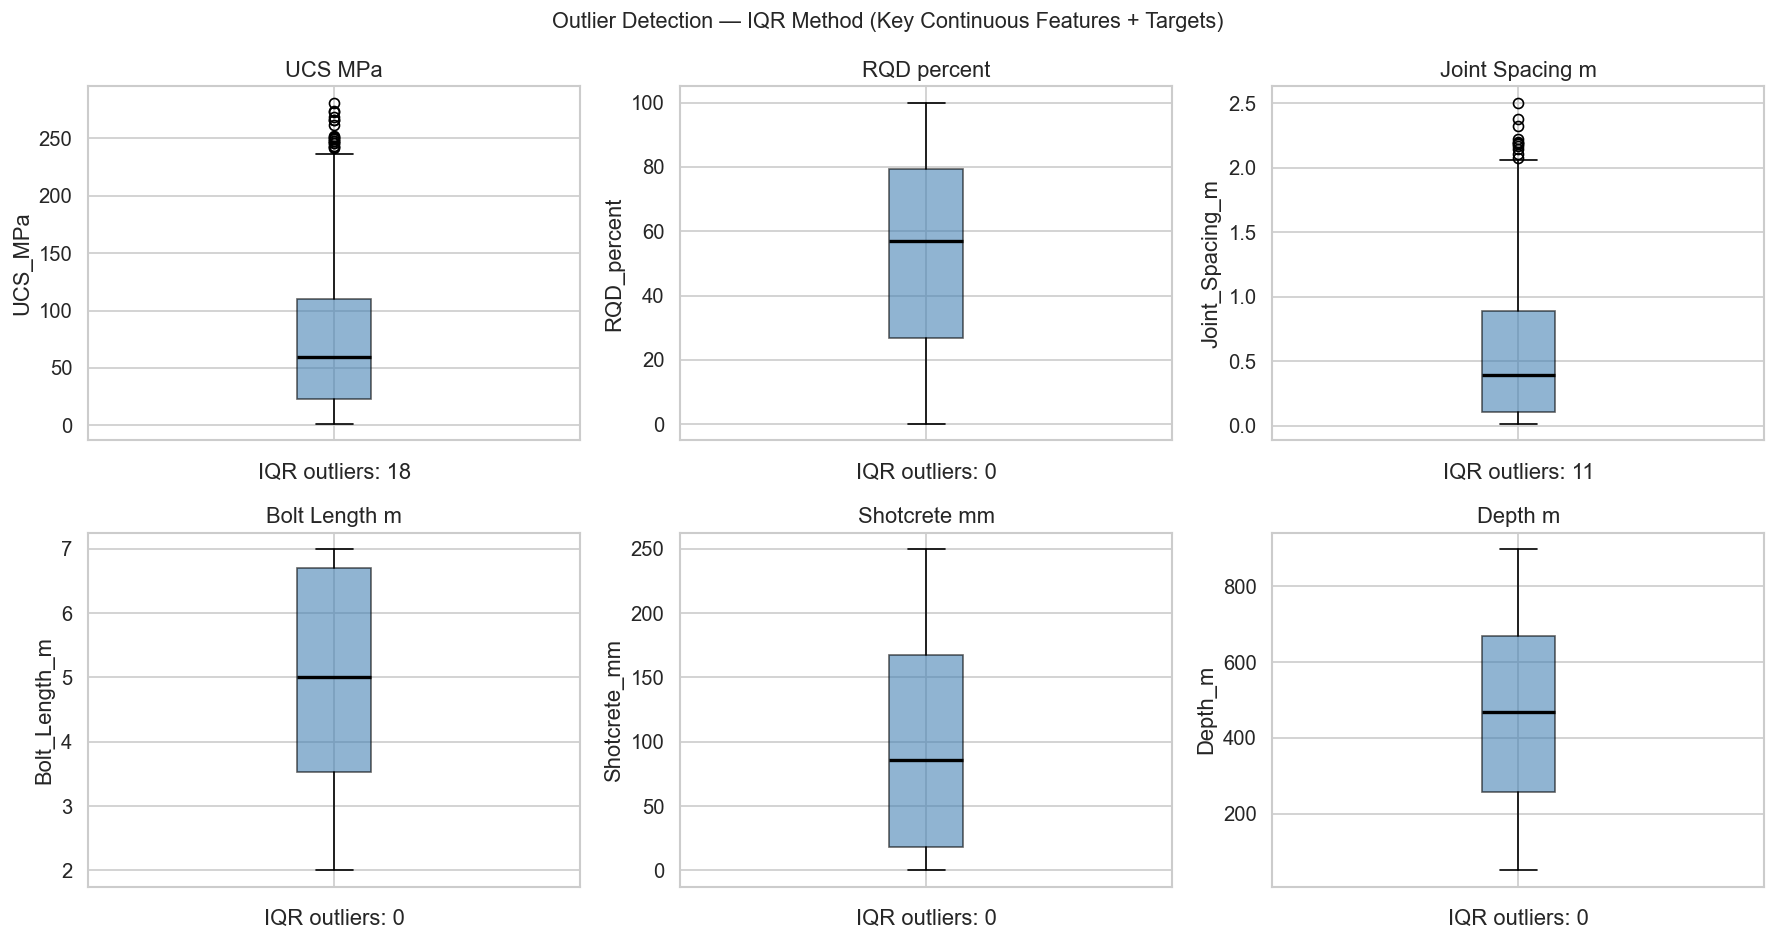

Note: UCS outliers are expected — Class I samples have high UCS (100-250 MPa)
while Class V samples cluster near 1-25 MPa, creating a wide joint distribution.


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

check_cols = ['UCS_MPa', 'RQD_percent', 'Joint_Spacing_m',
              'Bolt_Length_m', 'Shotcrete_mm', 'Depth_m']

for ax, feat in zip(axes.flat, check_cols):
    ax.boxplot(df[feat], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(feat.replace('_', ' '))
    ax.set_ylabel(feat)
    ax.set_xticklabels([])
    Q1  = df[feat].quantile(0.25)
    Q3  = df[feat].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'IQR outliers: {n_out}')

plt.suptitle('Outlier Detection — IQR Method (Key Continuous Features + Targets)', fontsize=13)
plt.tight_layout()
plt.savefig('fig19_outliers.png')
plt.show()

print('Note: UCS outliers are expected — Class I samples have high UCS (100-250 MPa)')
print('while Class V samples cluster near 1-25 MPa, creating a wide joint distribution.')

---
## 14. ANOVA F-Tests

Higher F = stronger class separator. Span, Depth and Method should score near zero
since they were sampled independently of class — confirming they add new information.


One-way ANOVA F-test — each feature vs True Rock Class
Higher F = stronger class separator = more useful predictor
Feature                         F-statistic        p-value
------------------------------------------------------------
UCS_MPa                               962.7       0.00e+00  ***
RQD_percent                          2181.3       0.00e+00  ***
Joint_Spacing_m                      1088.5       0.00e+00  ***
Joint_Condition                       540.1      1.48e-247  ***
Groundwater                           512.8      6.11e-240  ***
Joint_Orientation_adj                 505.1      9.11e-238  ***
Excavation_Span_m                       0.5       7.53e-01  n.s.
Depth_m                                 0.8       5.01e-01  n.s.
Excavation_Method                       0.9       4.64e-01  n.s.


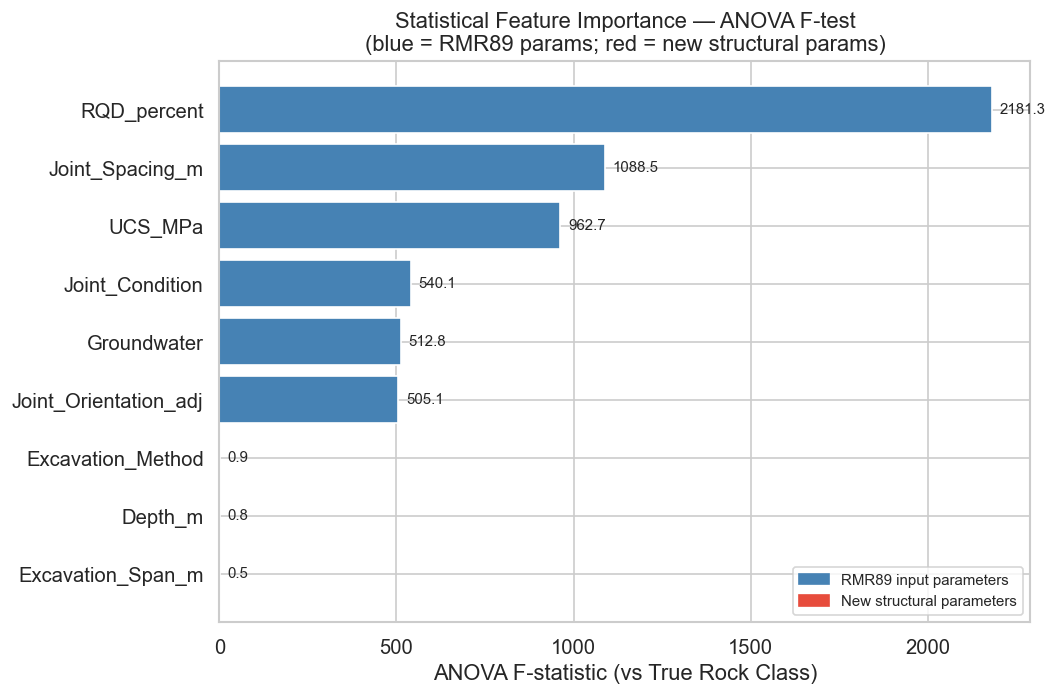


Expected: Span, Depth, Method have near-zero F (sampled independently of class).
This confirms they add NEW information not captured by the RMR89 features alone.


In [27]:
print('One-way ANOVA F-test — each feature vs True Rock Class')
print('Higher F = stronger class separator = more useful predictor')
print(f'{"Feature":<30} {"F-statistic":>12} {"p-value":>14}')
print('-' * 60)

f_scores = {}
for feat in FEATURE_COLS:
    groups  = [df[df[CLASS_COL]==c][feat].values for c in CLASS_ORDER]
    f_stat, p_val = stats.f_oneway(*groups)
    f_scores[feat] = f_stat
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'{feat:<30} {f_stat:>12.1f} {p_val:>14.2e}  {sig}')

fi_df = pd.DataFrame({'Feature': list(f_scores.keys()),
                      'F_stat':  list(f_scores.values())}).sort_values('F_stat')

# Colour bars by feature group
bar_colors = ['#e74c3c' if f in NEW_FEATURE_COLS else 'steelblue'
              for f in fi_df['Feature']]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi_df['Feature'], fi_df['F_stat'], color=bar_colors, edgecolor='white')
ax.set_xlabel('ANOVA F-statistic (vs True Rock Class)')
ax.set_title('Statistical Feature Importance — ANOVA F-test\n'
             '(blue = RMR89 params; red = new structural params)')
for i, (_, row) in enumerate(fi_df.iterrows()):
    ax.text(row['F_stat'] + max(fi_df['F_stat'])*0.01, i,
            f"{row['F_stat']:.1f}", va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color='steelblue', label='RMR89 input parameters'),
    mpatches.Patch(color='#e74c3c',   label='New structural parameters'),
]
ax.legend(handles=legend_patches, fontsize=9)
plt.tight_layout()
plt.savefig('fig20_anova.png')
plt.show()

print()
print('Expected: Span, Depth, Method have near-zero F (sampled independently of class).')
print('This confirms they add NEW information not captured by the RMR89 features alone.')

---
## 15. Summary Stats per Class


In [28]:
print('Mean ± Std per True Rock Class — ALL TARGETS:')
summary = df.groupby(CLASS_COL)[TARGET_COLS + ['Excavation_Span_m','Depth_m']].agg(['mean','std'])
summary.round(2).reindex(CLASS_ORDER)

Mean ± Std per True Rock Class — ALL TARGETS:


RMR       Bolt_Density_per_m2      Bolt_Length_m        \
                  mean   std                mean  std          mean   std   
True_Rock_Class                                                             
I                86.02  3.02                0.00  0.0          3.04  0.92   
II               71.66  5.49                0.16  0.0          3.58  0.69   
III              50.50  5.81                0.44  0.0          5.27  0.87   
IV               29.38  5.36                1.00  0.0          6.08  0.77   
V                 7.46  5.80                1.78  0.0          6.77  0.33   

                Shotcrete_mm        Excavation_Span_m       Depth_m          
                        mean    std              mean   std    mean     std  
True_Rock_Class                                                              
I                       0.00   0.00             10.17  3.58  466.62  244.93  
II                     26.68  10.47              9.88  3.38  462.03  240.23  
III                    96.19  34.13              9.98  3.42  486.64  237.89  
IV                    162.08  55.06              9.71  3.39  478.72  248.13  
V                     206.91  49.63              9.99  3.37  445.49  253.30

In [29]:
# Cross-tabulation: Excavation Method × Rock Class
print('Sample count by Rock Class and Excavation Method:')
ct = pd.crosstab(df['True_Rock_Class'], df['Excavation_Method'].map({0:'TBM',1:'D&B'}))
ct.index.name = 'Rock Class'
print(ct.reindex(CLASS_ORDER))

Sample count by Rock Class and Excavation Method:
Excavation_Method  D&B  TBM
Rock Class                 
I                   92  108
II                  89  111
III                100  100
IV                 106   94
V                   98  102


---
## 16. EDA Summary


In [30]:
shifted_pct = (
    (df['True_Rock_Class'] != df['Measured_Rock_Class']).mean() * 100
    if 'Measured_Rock_Class' in df.columns else 0.0
)

# Feature importances sorted
fi_sorted = pd.Series(f_scores).sort_values(ascending=False)

print('=' * 65)
print('EXTENDED EDA SUMMARY')
print('=' * 65)
print(f'Total samples              : {len(df)}')
print(f'Input features             : {len(FEATURE_COLS)} (6 RMR89 + Span + Depth + Method)')
print(f'Target variables           : {TARGET_COLS}')
print(f'Missing values             : {df.isnull().sum().sum()}')
print(f'Duplicate rows             : {df.duplicated().sum()}')
print(f'Class balance              : {dict(df[CLASS_COL].value_counts().sort_index())}')
print(f'Noise-shifted samples      : {shifted_pct:.1f}%')
print()
print('Target variable ranges:')
for col in TARGET_COLS:
    print(f'  {col:<25}: {df[col].min():.2f} — {df[col].max():.2f}  '
          f'(mean {df[col].mean():.2f})')
print()
print('Excavation span range      :', df.Excavation_Span_m.min(), '—', df.Excavation_Span_m.max(), 'm')
print('Depth range                :', df.Depth_m.min(), '—', df.Depth_m.max(), 'm')
print('Method split               : TBM={}, D&B={}'.format(
    (df.Excavation_Method==0).sum(), (df.Excavation_Method==1).sum()))
print()
print('ANOVA F-statistic ranking (all 9 features):')
for feat, val in fi_sorted.items():
    tag = '[NEW]' if feat in NEW_FEATURE_COLS else '     '
    print(f'  {tag} {feat:<28}: {val:.1f}')
print()
print('Key EDA findings:')
print('  1. Span and Depth are independent of rock class (F ≈ 0),')
print('     confirming they add complementary information.')
print('  2. Shotcrete and Bolt Length increase with span AND decrease with RMR,')
print('     consistent with published empirical equations.')
print('  3. TBM consistently requires ~10-20% less support than D&B')
print('     for identical rock class and span, as encoded from Barton et al. (1974).')
print('  4. Class V at depth > 400m shows depth_factor = 1.5 (squeezing),')
print('     resulting in shotcrete up to 250mm — consistent with deep mine case studies.')
print('  5. Within-class variance of Bolt Length and Shotcrete is substantial,')
print('     showing that rock class alone is not sufficient to determine support design.')
print()
print('Figures saved: fig1 to fig20 as PNG files.')
print('=' * 65)

EXTENDED EDA SUMMARY
Total samples              : 1000
Input features             : 9 (6 RMR89 + Span + Depth + Method)
Target variables           : ['RMR', 'Bolt_Density_per_m2', 'Bolt_Length_m', 'Shotcrete_mm']
Missing values             : 0
Duplicate rows             : 0
Class balance              : {'I': np.int64(200), 'II': np.int64(200), 'III': np.int64(200), 'IV': np.int64(200), 'V': np.int64(200)}
Noise-shifted samples      : 10.5%

Target variable ranges:
  RMR                      : -3.00 — 92.00  (mean 49.00)
  Bolt_Density_per_m2      : 0.00 — 1.78  (mean 0.68)
  Bolt_Length_m            : 2.00 — 7.00  (mean 4.95)
  Shotcrete_mm             : 0.00 — 250.00  (mean 98.37)

Excavation span range      : 4.02 — 16.0 m
Depth range                : 50.3 — 899.4 m
Method split               : TBM=515, D&B=485

ANOVA F-statistic ranking (all 9 features):
        RQD_percent                 : 2181.3
        Joint_Spacing_m             : 1088.5
        UCS_MPa                     : 96